# Türkiye İç Göç Atlası

### 2008–2025 TÜİK Verileriyle Türkiye'nin Göç Dinamiklerinin Analizi

**Python · Pandas · Scikit-learn · Plotly · NetworkX · Streamlit**

---

## 01 — Proje Tanımı

Bu vaka çalışması, Türkiye'deki iller arası göçün hacmini, yönünü, demografik bileşimini ve uzun dönemli il profillerini tekrar üretilebilir bir analiz hattıyla inceler.

> **Analiz soruları**  
> Yıllık hareketlilik nasıl değişti? Hangi iller çekim veya kayıp merkezi? En güçlü koridorlar hangileri? Yaş, cinsiyet, eğitim ve neden dağılımları ne söylüyor? İller uzun dönem davranışlarına göre hangi profillerde gruplanıyor?

> **Yorumlama sınırı**  
> Clustering sonucu bir gelecek tahmini veya nedensellik analizi değildir; benzer göç davranışlarının betimleyici segmentasyonudur.

### Notebook akışı

1. Veri kaynakları ve kalite kontrolleri
2. Uzun dönemli ve 2025 kesitli keşifçi analiz
3. Demografi, afet dönemi ve bölgeler arası akış vaka analizleri
4. Yönlü göç ağı
5. Feature engineering ve clustering karşılaştırması
6. PCA, cluster profilleri, sağlamlık ve sonuçlar

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import plotly.express as px
from IPython.display import Markdown, display
from sklearn.cluster import HDBSCAN

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODELS_DIR, PROCESSED_DATA_DIR
from src.data_cleaning import build_processed_datasets
from src.data_loader import (
    load_age_gender,
    load_age_gender_reason,
    load_city_summary,
    load_city_year_metrics,
    load_education_reason,
    load_migration_flows,
)
from src.feature_engineering import MODEL_FEATURES, build_long_term_features
from src.modeling import train_and_save_models
from src.network_analysis import province_network_metrics, strongest_corridors

NAVY, RED, BLUE, GRAY = "#14213D", "#9B1C31", "#3D5A80", "#667085"
plt.rcParams.update({"figure.figsize": (11, 5.5), "axes.titlesize": 15, "axes.labelsize": 11})

## 02 — Veri Kaynakları

| Veri seti | Gözlem seviyesi | Temel değişkenler | Kullanım |
|---|---|---|---|
| İller arası göç | Yıl × kaynak il × hedef il | Akış, ters akış, nüfus | 2008–2025 trend, koridor, ağ ve model özellikleri |
| İllerin göç özeti | İl | Giriş, çıkış, net göç, net hız | 2025 resmi uzlaştırma |
| Yaş ve cinsiyet | Yaş grubu | Erkek, kadın, toplam | Demografik profil |
| Yaş × cinsiyet × neden | Yaş grubu × cinsiyet × neden | Kişi sayısı | Yaş ve cinsiyet motivasyonları |
| Eğitim × neden | Eğitim düzeyi × neden | Kişi sayısı | Eğitim-motivasyon ilişkisi (6+ yaş) |

Tüm kaynaklar TÜİK İç Göç İstatistikleri tablolarıdır. Yardımcı demografi tabloları 2025 kesitidir.

## 03 — Veri Kalitesi ve Temizleme

In [2]:
processed = build_processed_datasets()
flows = load_migration_flows()
city_summary = load_city_summary()
city_year = load_city_year_metrics()
age_gender = load_age_gender()
age_reason = load_age_gender_reason()
education_reason = load_education_reason()

dataset_overview = pd.DataFrame(
    [
        {"Veri seti": name, "Satır": len(frame), "Sütun": frame.shape[1]}
        for name, frame in processed.items()
    ]
)
dataset_overview

,Veri seti,Satır,Sütun
0,iller_arasi_goc.csv,116640,8
1,illerin_goc_ozeti.csv,81,7
2,yas_cinsiyet_goc.csv,14,5
3,yas_cinsiyet_neden.csv,336,5
4,egitim_goc_nedeni.csv,84,4
5,city_year_metrics.csv,1458,12


In [3]:
quality_summary = pd.DataFrame(
    {
        "Kontrol": [
            "Yıl aralığı",
            "Benzersiz hedef il",
            "Her yıl kaynak–hedef satırı",
            "Duplicate kaynak–hedef-yıl",
            "Self-loop",
            "Eksik ana akış değeri",
            "Negatif akış",
            "2025 resmi özet uzlaşması",
        ],
        "Sonuç": [
            f"{flows.year.min()}–{flows.year.max()} ({flows.year.nunique()} yıl)",
            flows.destination_province.nunique(),
            int(flows.groupby("year").size().min()),
            int(flows.duplicated(["year", "destination_province", "origin_province"]).sum()),
            int(flows.destination_province.eq(flows.origin_province).sum()),
            int(flows.isna().sum().sum()),
            int(flows.migration_flow.lt(0).sum()),
            "81 / 81 il",
        ],
        "Durum": ["Geçti"] * 8,
    }
)
quality_summary

,Kontrol,Sonuç,Durum
0,Yıl aralığı,2008–2025 (18 yıl),Geçti
1,Benzersiz hedef il,81,Geçti
2,Her yıl kaynak–hedef satırı,6480,Geçti
3,Duplicate kaynak–hedef-yıl,0,Geçti
4,Self-loop,0,Geçti
5,Eksik ana akış değeri,0,Geçti
6,Negatif akış,0,Geçti
7,2025 resmi özet uzlaşması,81 / 81 il,Geçti


> **Metodoloji notu**  
> Ham dosyalardaki kaynak, İngilizce metadata, dipnot ve *Toplam* satırları processed katmana alınmadı. `-` işareti sessizce sıfıra çevrilmedi; bilgi-yok değeri olarak korundu. Her yıl 81×80 yönlü il çifti beklenir.

## 04 — Keşifçi Veri Analizi

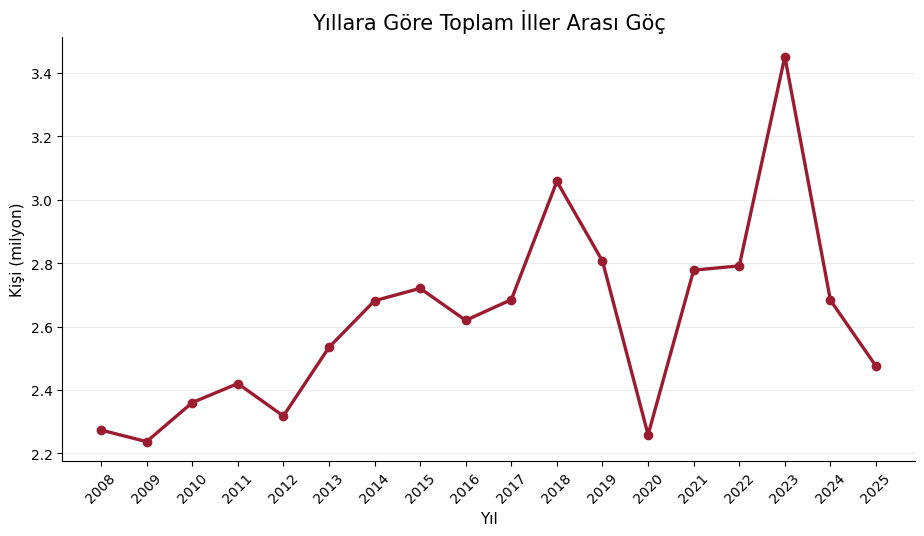

**Temel bulgu.** Dönem zirvesi 2023 yılında 3,450,953 kişidir. 2025 toplamı 2024'e göre %7.7 azalmıştır.

In [4]:
yearly = city_year.groupby("year", as_index=False)["in_migration"].sum()
fig, ax = plt.subplots()
ax.plot(yearly.year, yearly.in_migration / 1_000_000, color=RED, marker="o", linewidth=2.4)
ax.set(title="Yıllara Göre Toplam İller Arası Göç", xlabel="Yıl", ylabel="Kişi (milyon)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_xticks(yearly.year)
ax.tick_params(axis="x", rotation=45)
plt.show()

peak = yearly.loc[yearly.in_migration.idxmax()]
change_2025 = 100 * (yearly.set_index("year").loc[2025, "in_migration"] / yearly.set_index("year").loc[2024, "in_migration"] - 1)
display(Markdown(
    f"**Temel bulgu.** Dönem zirvesi {int(peak.year)} yılında {int(peak.in_migration):,} kişidir. "
    f"2025 toplamı 2024'e göre %{abs(change_2025):.1f} azalmıştır."
))

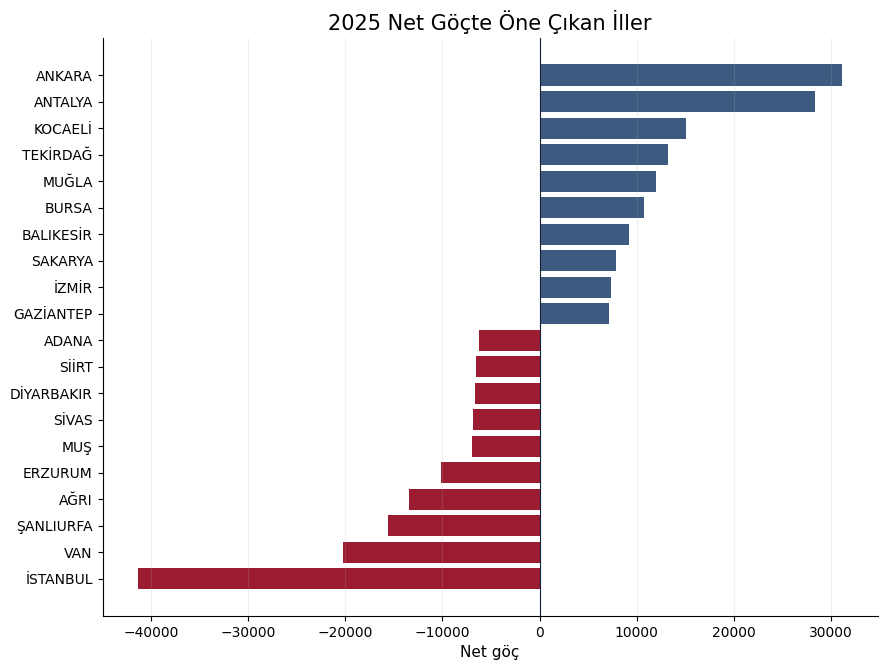

**Temel bulgu.** Ankara +31,172 kişiyle en yüksek mutlak net kazancı, İstanbul -41,346 kişiyle en yüksek net kaybı kaydetmiştir.

In [5]:
latest = city_year.loc[city_year.year.eq(2025)]
extremes = pd.concat([
    latest.nlargest(10, "net_migration"),
    latest.nsmallest(10, "net_migration"),
]).sort_values("net_migration")

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.barh(extremes.province, extremes.net_migration, color=np.where(extremes.net_migration >= 0, BLUE, RED))
ax.axvline(0, color=NAVY, linewidth=0.8)
ax.set(title="2025 Net Göçte Öne Çıkan İller", xlabel="Net göç", ylabel="")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.show()

top_gain = latest.loc[latest.net_migration.idxmax()]
top_loss = latest.loc[latest.net_migration.idxmin()]
display(Markdown(
    f"**Temel bulgu.** Ankara +{top_gain.net_migration:,} kişiyle en yüksek mutlak net kazancı, "
    f"İstanbul {top_loss.net_migration:,} kişiyle en yüksek net kaybı kaydetmiştir."
))

### 04.1 — Giriş ve Çıkış Hacmi

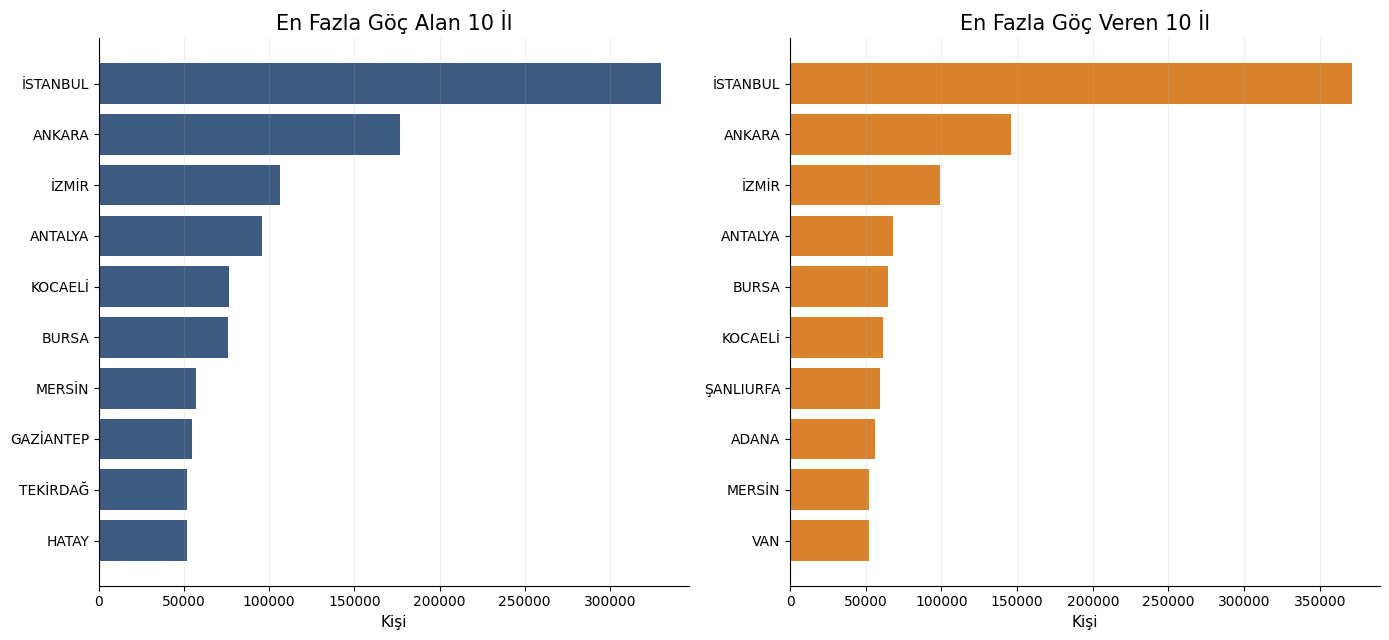

**Veri temelli yorum.** İSTANBUL, 329,912 kişilik girişle en fazla göç alan; İSTANBUL, 371,258 kişilik çıkışla en fazla göç veren ildir. Aynı ilin iki listede de ilk sırada bulunması, net dengeden bağımsız olarak yüksek sirkülasyona işaret eder.

In [6]:
top_in = latest.nlargest(10, "in_migration").sort_values("in_migration")
top_out = latest.nlargest(10, "out_migration").sort_values("out_migration")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
axes[0].barh(top_in.province, top_in.in_migration, color=BLUE)
axes[0].set(title="En Fazla Göç Alan 10 İl", xlabel="Kişi", ylabel="")
axes[1].barh(top_out.province, top_out.out_migration, color="#D9822B")
axes[1].set(title="En Fazla Göç Veren 10 İl", xlabel="Kişi", ylabel="")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

leader_in, leader_out = top_in.iloc[-1], top_out.iloc[-1]
display(Markdown(
    f"**Veri temelli yorum.** {leader_in.province}, {leader_in.in_migration:,.0f} kişilik girişle en fazla göç alan; "
    f"{leader_out.province}, {leader_out.out_migration:,.0f} kişilik çıkışla en fazla göç veren ildir. "
    "Aynı ilin iki listede de ilk sırada bulunması, net dengeden bağımsız olarak yüksek sirkülasyona işaret eder."
))

### 04.2 — Nüfusa Oranlı Net Göç Hızı

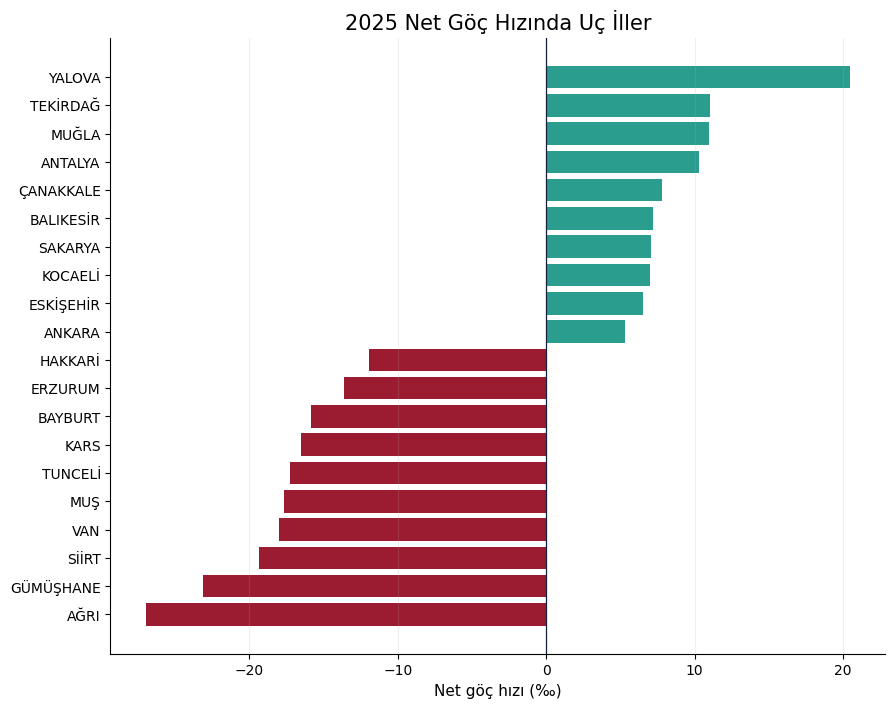

**Veri temelli yorum.** Nüfusa oranlandığında en yüksek net göç hızı YALOVA'da ‰20.5; en düşük hız AĞRI'da ‰-27.0. Mutlak net göç ile oranlı hız farklı soruları yanıtlar; küçük illerde daha düşük sayılar daha büyük demografik etki yaratabilir.

In [7]:
rate_extremes = pd.concat([
    latest.nlargest(10, "net_migration_rate"),
    latest.nsmallest(10, "net_migration_rate"),
]).drop_duplicates("province").sort_values("net_migration_rate")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    rate_extremes.province,
    rate_extremes.net_migration_rate,
    color=np.where(rate_extremes.net_migration_rate >= 0, "#2A9D8F", RED),
)
ax.axvline(0, color=NAVY, linewidth=0.9)
ax.set(title="2025 Net Göç Hızında Uç İller", xlabel="Net göç hızı (‰)", ylabel="")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.show()

rate_high = latest.loc[latest.net_migration_rate.idxmax()]
rate_low = latest.loc[latest.net_migration_rate.idxmin()]
display(Markdown(
    f"**Veri temelli yorum.** Nüfusa oranlandığında en yüksek net göç hızı {rate_high.province}'da "
    f"‰{rate_high.net_migration_rate:.1f}; en düşük hız {rate_low.province}'da ‰{rate_low.net_migration_rate:.1f}. "
    "Mutlak net göç ile oranlı hız farklı soruları yanıtlar; küçük illerde daha düşük sayılar daha büyük demografik etki yaratabilir."
))

### 04.3 — Büyükşehirler Arası Akış Matrisi

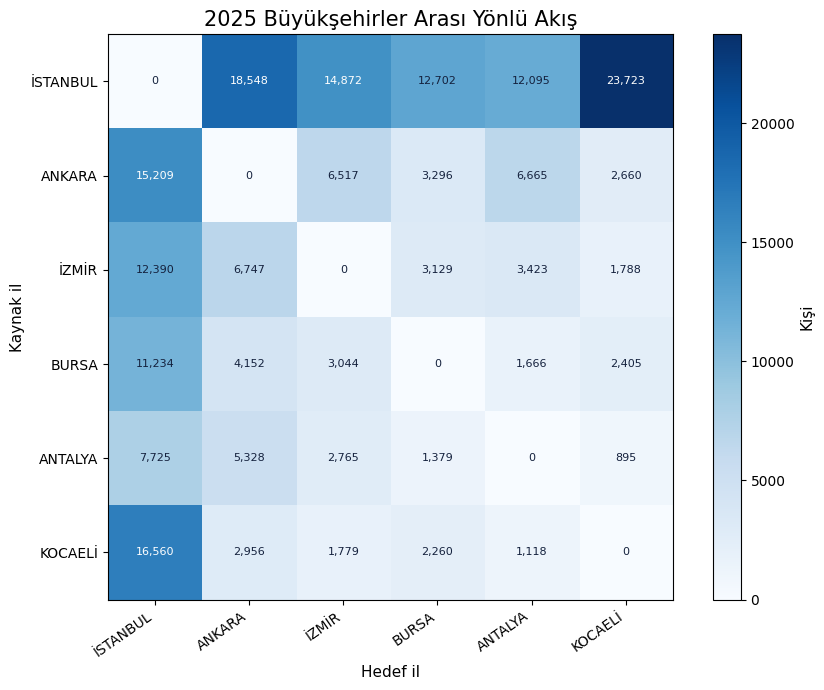

**Veri temelli yorum.** Seçili altı büyükşehir arasında en yüksek yönlü akış İSTANBUL → KOCAELİ: 23,723 kişidir. Matris karşılıklı yönleri ayrı hücrelerde göstererek koridorlardaki asimetriyi korur.

In [8]:
metros = ["İSTANBUL", "ANKARA", "İZMİR", "BURSA", "ANTALYA", "KOCAELİ"]
metro_flows = flows.loc[
    flows.year.eq(2025)
    & flows.origin_province.isin(metros)
    & flows.destination_province.isin(metros)
]
metro_matrix = metro_flows.pivot(
    index="origin_province", columns="destination_province", values="migration_flow"
).reindex(index=metros, columns=metros)
np.fill_diagonal(metro_matrix.values, 0)  # Self-loop kaynakta yapısal olarak bulunmuyor.

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(metro_matrix, cmap="Blues")
for row in range(len(metros)):
    for column in range(len(metros)):
        value = metro_matrix.iloc[row, column]
        ax.text(column, row, f"{value:,.0f}", ha="center", va="center", fontsize=8,
                color="white" if value > metro_matrix.to_numpy().max() * 0.55 else NAVY)
ax.set_xticks(range(len(metros)), metros, rotation=35, ha="right")
ax.set_yticks(range(len(metros)), metros)
ax.set(title="2025 Büyükşehirler Arası Yönlü Akış", xlabel="Hedef il", ylabel="Kaynak il")
fig.colorbar(image, ax=ax, label="Kişi")
plt.tight_layout()
plt.show()

metro_top = metro_flows.nlargest(1, "migration_flow").iloc[0]
display(Markdown(
    f"**Veri temelli yorum.** Seçili altı büyükşehir arasında en yüksek yönlü akış "
    f"{metro_top.origin_province} → {metro_top.destination_province}: {metro_top.migration_flow:,.0f} kişidir. "
    "Matris karşılıklı yönleri ayrı hücrelerde göstererek koridorlardaki asimetriyi korur."
))

### 04.4 — İstanbul ve Ankara'nın Başlıca Bağlantıları

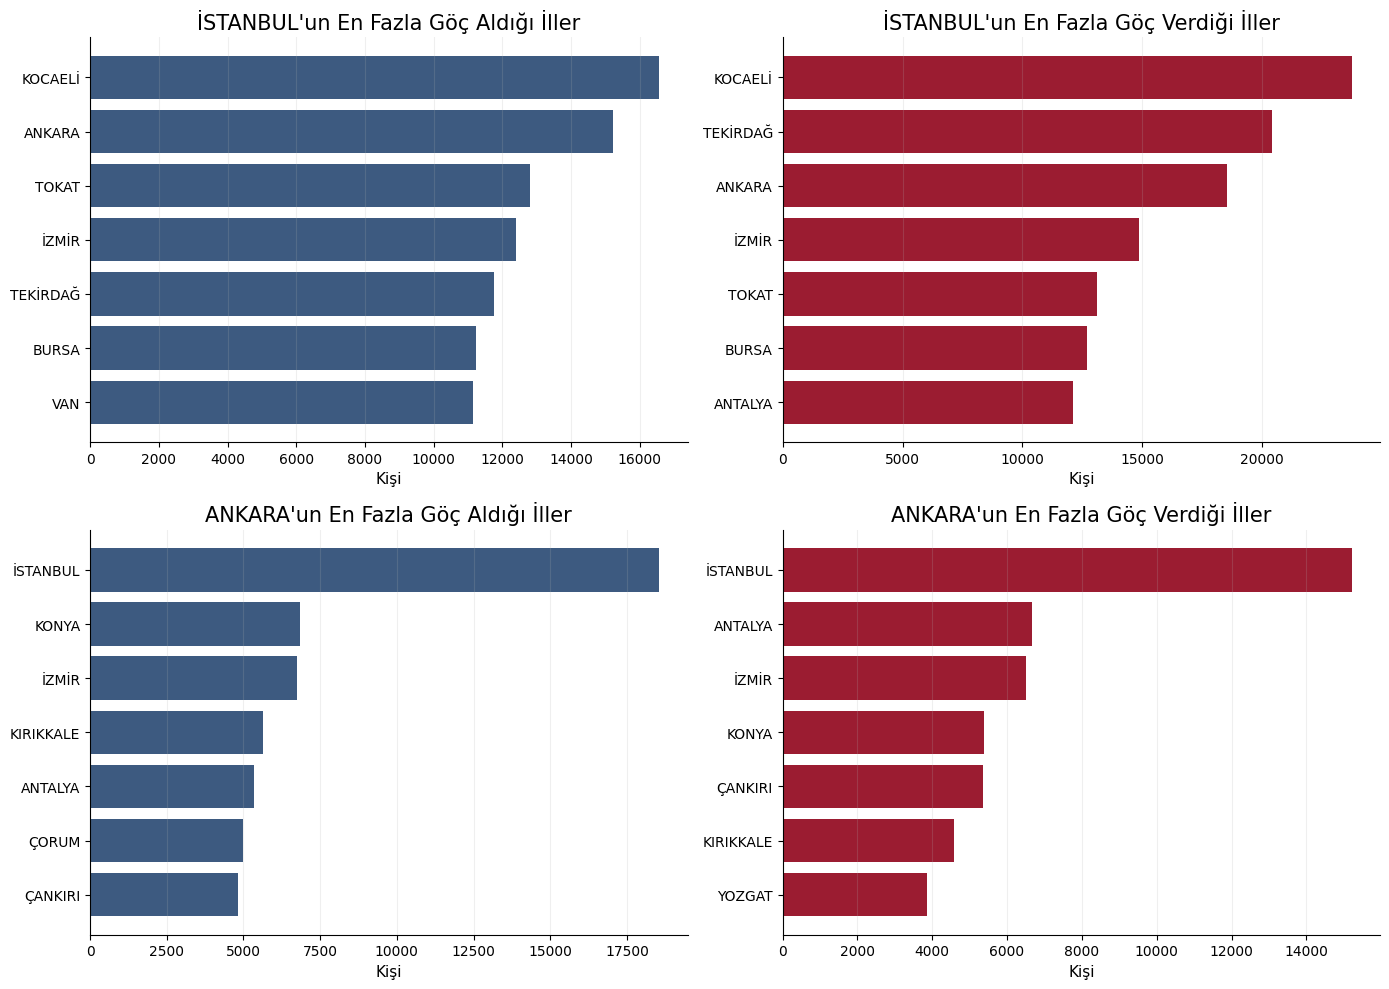

**Veri temelli yorum.** İstanbul'un en büyük çıkış bağlantısı KOCAELİ (23,723 kişi); Ankara'nın en büyük giriş kaynağı İSTANBUL (18,548 kişi). Bu grafikler toplam hacim sıralamasını koridor bileşimiyle tamamlar.

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, province in enumerate(["İSTANBUL", "ANKARA"]):
    incoming = flows.loc[
        flows.year.eq(2025) & flows.destination_province.eq(province)
    ].nlargest(7, "migration_flow").sort_values("migration_flow")
    outgoing = flows.loc[
        flows.year.eq(2025) & flows.origin_province.eq(province)
    ].nlargest(7, "migration_flow").sort_values("migration_flow")
    axes[row, 0].barh(incoming.origin_province, incoming.migration_flow, color=BLUE)
    axes[row, 0].set_title(f"{province}'un En Fazla Göç Aldığı İller")
    axes[row, 1].barh(outgoing.destination_province, outgoing.migration_flow, color=RED)
    axes[row, 1].set_title(f"{province}'un En Fazla Göç Verdiği İller")
    for ax in axes[row]:
        ax.set_xlabel("Kişi")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

istanbul_out = flows.loc[
    flows.year.eq(2025) & flows.origin_province.eq("İSTANBUL")
].nlargest(1, "migration_flow").iloc[0]
ankara_in = flows.loc[
    flows.year.eq(2025) & flows.destination_province.eq("ANKARA")
].nlargest(1, "migration_flow").iloc[0]
display(Markdown(
    f"**Veri temelli yorum.** İstanbul'un en büyük çıkış bağlantısı {istanbul_out.destination_province} "
    f"({istanbul_out.migration_flow:,.0f} kişi); Ankara'nın en büyük giriş kaynağı "
    f"{ankara_in.origin_province} ({ankara_in.migration_flow:,.0f} kişi). Bu grafikler toplam hacim sıralamasını koridor bileşimiyle tamamlar."
))

### 04.5 — Seçili İllerin Uzun Dönemli Net Göç Hızı

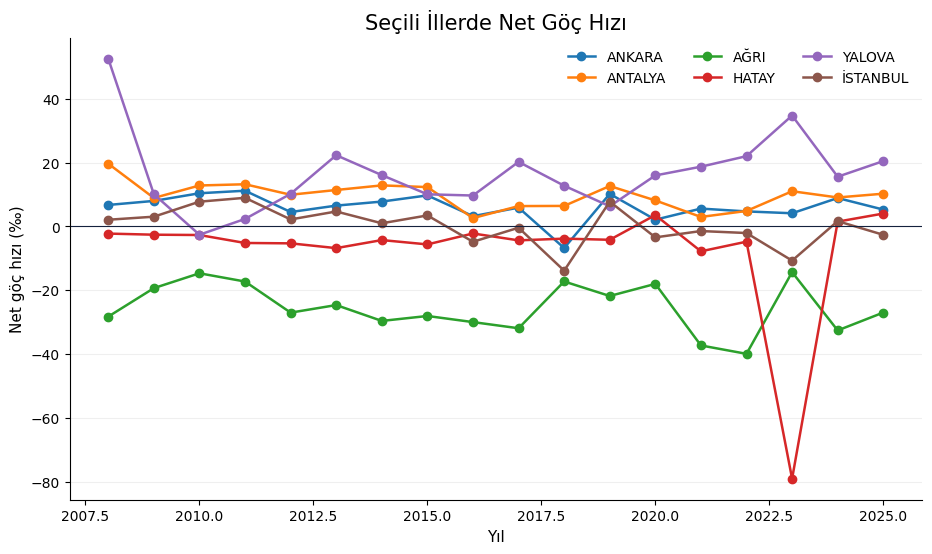

In [10]:
selected_provinces = ["İSTANBUL", "ANKARA", "ANTALYA", "HATAY", "AĞRI", "YALOVA"]
trend_data = city_year.loc[city_year.province.isin(selected_provinces)]
fig, ax = plt.subplots(figsize=(11, 6))
for province, history in trend_data.groupby("province"):
    ax.plot(history.year, history.net_migration_rate, marker="o", linewidth=1.8, label=province)
ax.axhline(0, color=NAVY, linewidth=0.8)
ax.set(title="Seçili İllerde Net Göç Hızı", xlabel="Yıl", ylabel="Net göç hızı (‰)")
ax.legend(frameon=False, ncol=3)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.show()

### 04.6 — 2025'in En Güçlü Göç Koridorları

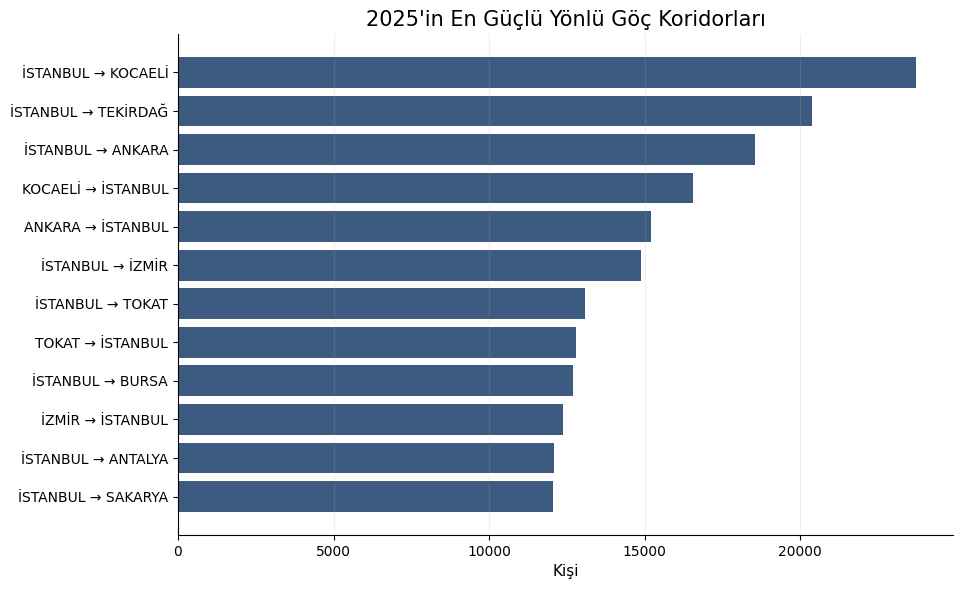

**Temel bulgu.** En büyük yönlü akış İSTANBUL → KOCAELİ: 23,723 kişi.

In [11]:
corridors = strongest_corridors(flows, 2025, top_n=12).sort_values("flow")
labels = corridors.origin + " → " + corridors.destination
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(labels, corridors.flow, color=BLUE)
ax.set(title="2025'in En Güçlü Yönlü Göç Koridorları", xlabel="Kişi", ylabel="")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.show()

leader = corridors.iloc[-1]
display(Markdown(f"**Temel bulgu.** En büyük yönlü akış {leader.origin} → {leader.destination}: {leader.flow:,} kişi."))

### 04.7 — Yaş ve Cinsiyet Profili

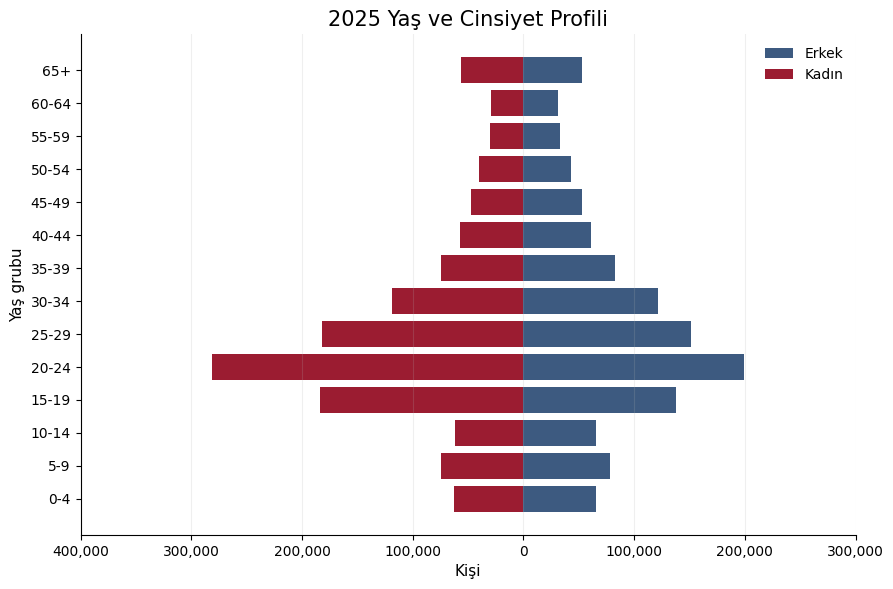

**Temel bulgu.** En hareketli yaş grubu 20-24 (480,185 kişi). Toplamda 1,298,685 kadın ve 1,176,334 erkek göç etmiştir.

In [12]:
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(age_gender.age_group, age_gender.male, color=BLUE, label="Erkek")
ax.barh(age_gender.age_group, -age_gender.female, color=RED, label="Kadın")
ticks = ax.get_xticks()
ax.set_xticks(ticks, [f"{abs(int(value)):,}" for value in ticks])
ax.set(title="2025 Yaş ve Cinsiyet Profili", xlabel="Kişi", ylabel="Yaş grubu")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.show()

top_age = age_gender.loc[age_gender.total.idxmax()]
display(Markdown(
    f"**Temel bulgu.** En hareketli yaş grubu {top_age.age_group} ({top_age.total:,} kişi). "
    f"Toplamda {age_gender.female.sum():,} kadın ve {age_gender.male.sum():,} erkek göç etmiştir."
))

### 04.8 — Göç Nedenleri, Eğitim ve Yaş

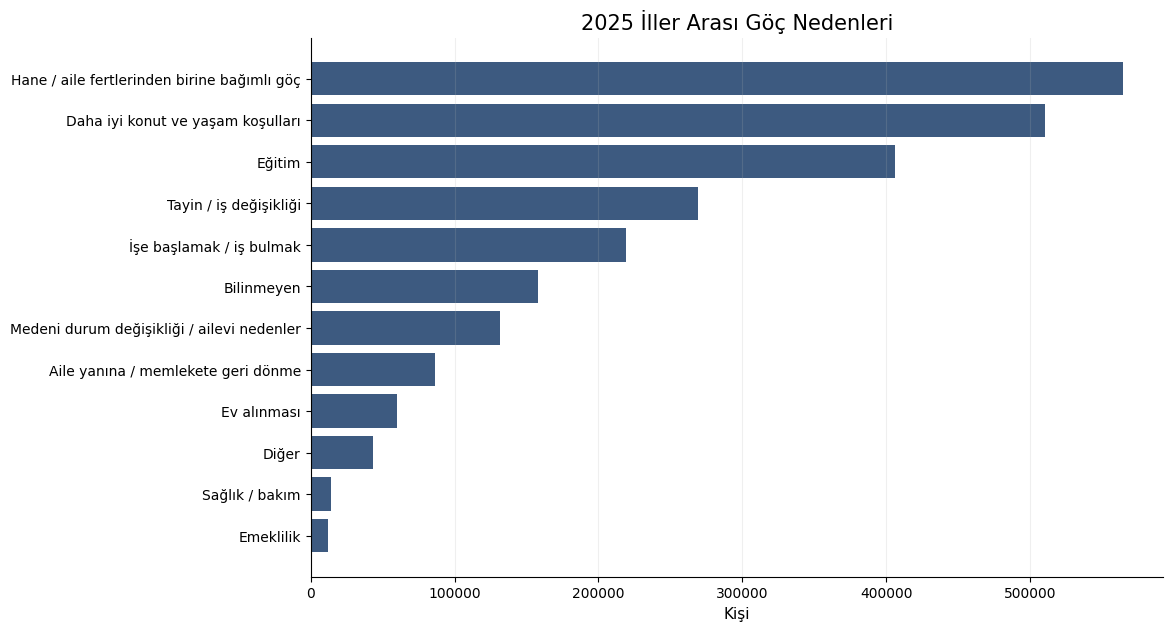

**Temel bulgu.** En yaygın neden Hane / aile fertlerinden birine bağımlı göç: 564,114 kişi.

In [13]:
reason_totals = (
    age_reason.groupby("reason", as_index=False)
    .agg(count=("count", lambda values: values.sum(min_count=1)))
    .sort_values("count")
)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(reason_totals.reason, reason_totals["count"], color=BLUE)
ax.set(title="2025 İller Arası Göç Nedenleri", xlabel="Kişi", ylabel="")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.show()

top_reason = reason_totals.iloc[-1]
display(Markdown(f"**Temel bulgu.** En yaygın neden {top_reason.reason}: {int(top_reason['count']):,} kişi."))

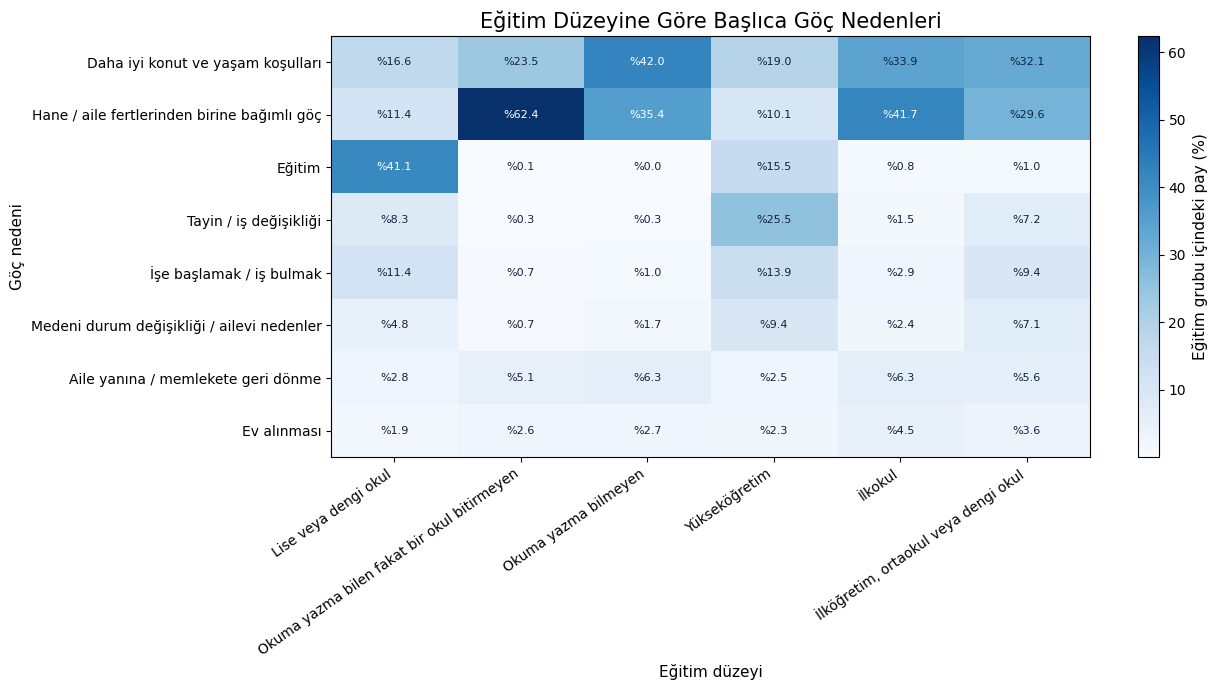

**Veri temelli yorum.** Yükseköğretim grubunda en yüksek iki pay Tayin / iş değişikliği (%25.5) ve Daha iyi konut ve yaşam koşulları (%19.0) nedenlerindedir. Yüzdeler her eğitim sütununun kendi toplamına göre hesaplanır; tablo 6+ yaş evrenini temsil eder.

In [14]:
education_known = education_reason.loc[
    education_reason.education_level.ne("Bilinmeyen")
    & education_reason.reason.ne("Bilinmeyen")
]
education_matrix = education_known.pivot_table(
    index="reason", columns="education_level", values="count", aggfunc="sum"
)
top_education_reasons = education_matrix.sum(axis=1, min_count=1).nlargest(8).index
education_share = education_matrix.div(education_matrix.sum(axis=0), axis=1).loc[top_education_reasons]

fig, ax = plt.subplots(figsize=(13, 7))
masked = np.ma.masked_invalid(education_share.to_numpy(dtype=float) * 100)
image = ax.imshow(masked, cmap="Blues", aspect="auto")
for row in range(education_share.shape[0]):
    for column in range(education_share.shape[1]):
        value = education_share.iloc[row, column]
        if pd.notna(value):
            ax.text(column, row, f"%{value * 100:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if value > np.nanmax(education_share.to_numpy()) * 0.55 else NAVY)
ax.set_xticks(range(education_share.shape[1]), education_share.columns, rotation=35, ha="right")
ax.set_yticks(range(education_share.shape[0]), education_share.index)
ax.set(title="Eğitim Düzeyine Göre Başlıca Göç Nedenleri", xlabel="Eğitim düzeyi", ylabel="Göç nedeni")
fig.colorbar(image, ax=ax, label="Eğitim grubu içindeki pay (%)")
plt.tight_layout()
plt.show()

higher = education_share["Yükseköğretim"].sort_values(ascending=False).head(2)
display(Markdown(
    f"**Veri temelli yorum.** Yükseköğretim grubunda en yüksek iki pay "
    f"{higher.index[0]} (%{higher.iloc[0] * 100:.1f}) ve {higher.index[1]} (%{higher.iloc[1] * 100:.1f}) nedenlerindedir. "
    "Yüzdeler her eğitim sütununun kendi toplamına göre hesaplanır; tablo 6+ yaş evrenini temsil eder."
))

> **Kapsam notu**  
> Eğitim × neden görseli her eğitim grubunun kendi içindeki neden dağılımını gösterir. Kaynak tablo 6+ yaşı kapsadığı için toplam göç nüfusuyla aynı evren olarak yorumlanmaz.

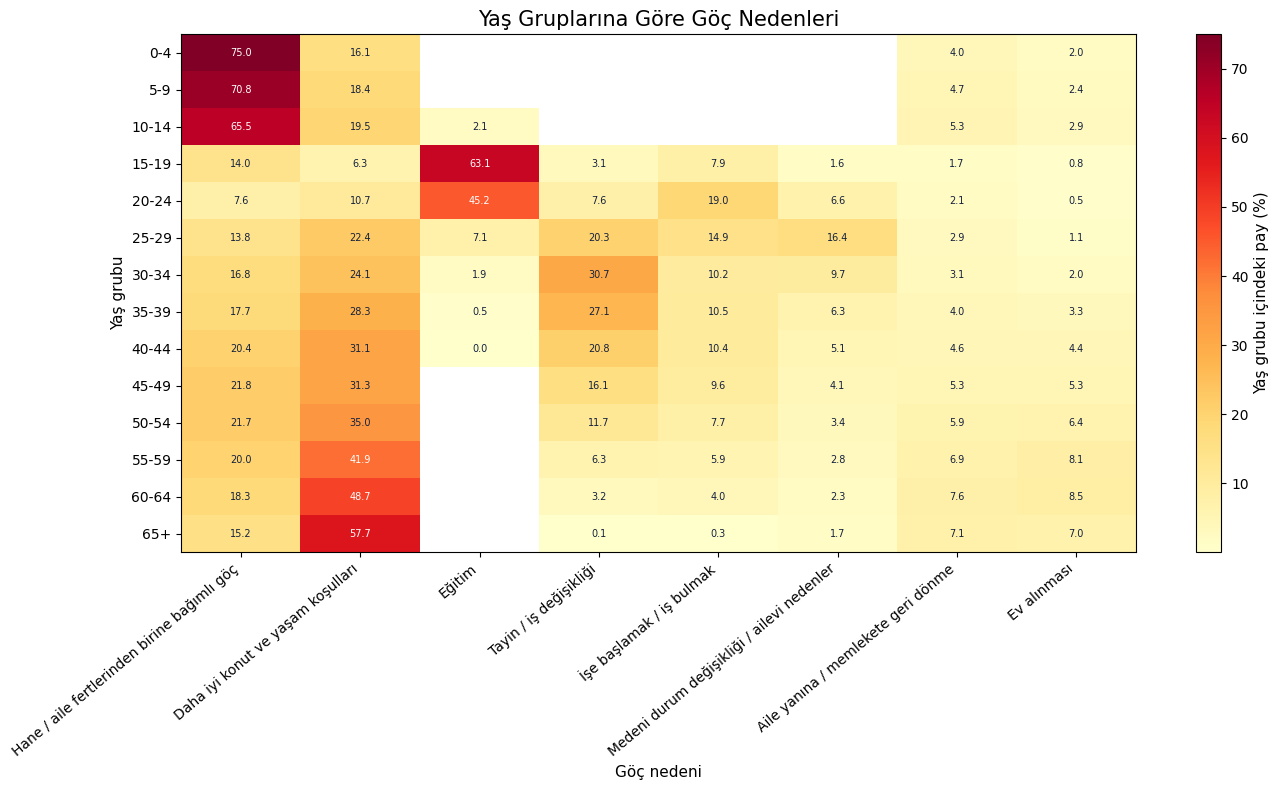

**Veri temelli yorum.** 20–24 yaş grubunda ilk iki neden Eğitim (%45.2) ve İşe başlamak / iş bulmak (%19.0); 65+ grupta Daha iyi konut ve yaşam koşulları (%57.7) ve Hane / aile fertlerinden birine bağımlı göç (%15.2). Yaşla birlikte motivasyon bileşiminin belirgin biçimde değiştiği görülür.

In [15]:
age_reason_known = age_reason.loc[age_reason.reason.ne("Bilinmeyen")]
age_reason_matrix = (
    age_reason_known.groupby(["age_group", "reason"], as_index=False)["count"]
    .sum(min_count=1)
    .pivot(index="age_group", columns="reason", values="count")
    .reindex(age_gender.age_group)
)
age_reason_share = age_reason_matrix.div(age_reason_matrix.sum(axis=1), axis=0)
top_age_reasons = age_reason_matrix.sum(axis=0, min_count=1).nlargest(8).index
age_reason_plot = age_reason_share[top_age_reasons]

fig, ax = plt.subplots(figsize=(14, 8))
masked = np.ma.masked_invalid(age_reason_plot.to_numpy(dtype=float) * 100)
image = ax.imshow(masked, cmap="YlOrRd", aspect="auto")
for row in range(age_reason_plot.shape[0]):
    for column in range(age_reason_plot.shape[1]):
        value = age_reason_plot.iloc[row, column]
        if pd.notna(value):
            ax.text(column, row, f"{value * 100:.1f}", ha="center", va="center", fontsize=7,
                    color="white" if value > np.nanmax(age_reason_plot.to_numpy()) * 0.55 else NAVY)
ax.set_xticks(range(age_reason_plot.shape[1]), age_reason_plot.columns, rotation=40, ha="right")
ax.set_yticks(range(age_reason_plot.shape[0]), age_reason_plot.index)
ax.set(title="Yaş Gruplarına Göre Göç Nedenleri", xlabel="Göç nedeni", ylabel="Yaş grubu")
fig.colorbar(image, ax=ax, label="Yaş grubu içindeki pay (%)")
plt.tight_layout()
plt.show()

young = age_reason_share.loc["20-24"].sort_values(ascending=False).head(2)
senior = age_reason_share.loc["65+"].sort_values(ascending=False).head(2)
display(Markdown(
    f"**Veri temelli yorum.** 20–24 yaş grubunda ilk iki neden {young.index[0]} (%{young.iloc[0] * 100:.1f}) ve "
    f"{young.index[1]} (%{young.iloc[1] * 100:.1f}); 65+ grupta {senior.index[0]} (%{senior.iloc[0] * 100:.1f}) ve "
    f"{senior.index[1]} (%{senior.iloc[1] * 100:.1f}). Yaşla birlikte motivasyon bileşiminin belirgin biçimde değiştiği görülür."
))

### 04.9 — Cinsiyete Göre Göç Nedenleri

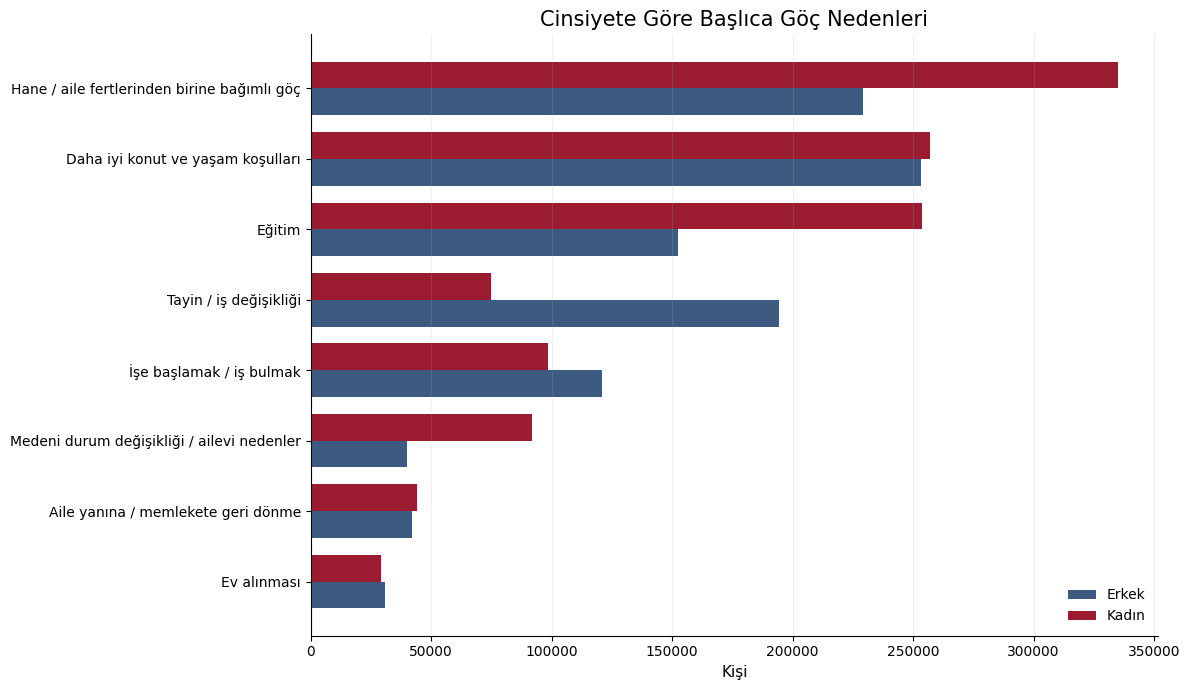

**Veri temelli yorum.** Seçili nedenler içinde kadın ve erkek sayıları arasındaki en büyük mutlak fark Tayin / iş değişikliği nedenindedir: kadın 74,923, erkek 194,230. Bu fark neden kaydını betimler; tek başına davranışsal veya nedensel açıklama sunmaz.

In [16]:
gender_reason = (
    age_reason.loc[age_reason.reason.ne("Bilinmeyen")]
    .groupby(["sex", "reason"], as_index=False)["count"]
    .sum(min_count=1)
)
top_gender_reasons = gender_reason.groupby("reason")["count"].sum(min_count=1).nlargest(8).index
gender_plot = gender_reason.loc[gender_reason.reason.isin(top_gender_reasons)]
reason_order = gender_plot.groupby("reason")["count"].sum().sort_values().index
x = np.arange(len(reason_order))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 7))
for offset, (sex, color) in zip([-width / 2, width / 2], [("Erkek", BLUE), ("Kadın", RED)]):
    values = gender_plot.loc[gender_plot.sex.eq(sex)].set_index("reason").reindex(reason_order)["count"]
    ax.barh(x + offset, values, height=width, label=sex, color=color)
ax.set_yticks(x, reason_order)
ax.set(title="Cinsiyete Göre Başlıca Göç Nedenleri", xlabel="Kişi", ylabel="")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

gender_pivot = gender_plot.pivot(index="reason", columns="sex", values="count")
largest_gap = (gender_pivot["Kadın"] - gender_pivot["Erkek"]).abs().idxmax()
display(Markdown(
    f"**Veri temelli yorum.** Seçili nedenler içinde kadın ve erkek sayıları arasındaki en büyük mutlak fark "
    f"{largest_gap} nedenindedir: kadın {gender_pivot.loc[largest_gap, 'Kadın']:,.0f}, "
    f"erkek {gender_pivot.loc[largest_gap, 'Erkek']:,.0f}. Bu fark neden kaydını betimler; tek başına davranışsal veya nedensel açıklama sunmaz."
))

### 04.10 — 2023 Depremi Çevresinde Göç Hareketleri

> **Bağlam ve sınır**  
> Aşağıdaki dört il, 6 Şubat 2023 depremlerinden ağır etkilenen illere odaklanan betimleyici bir vaka kesitidir. Zaman birlikteliği nedensellik kanıtı değildir; ekonomik koşullar, idari kayıtlar ve yeniden yerleşim politikaları gibi başka etkenler de sonuçları etkileyebilir. Bu il etiketi clustering modeline dahil edilmemiştir.

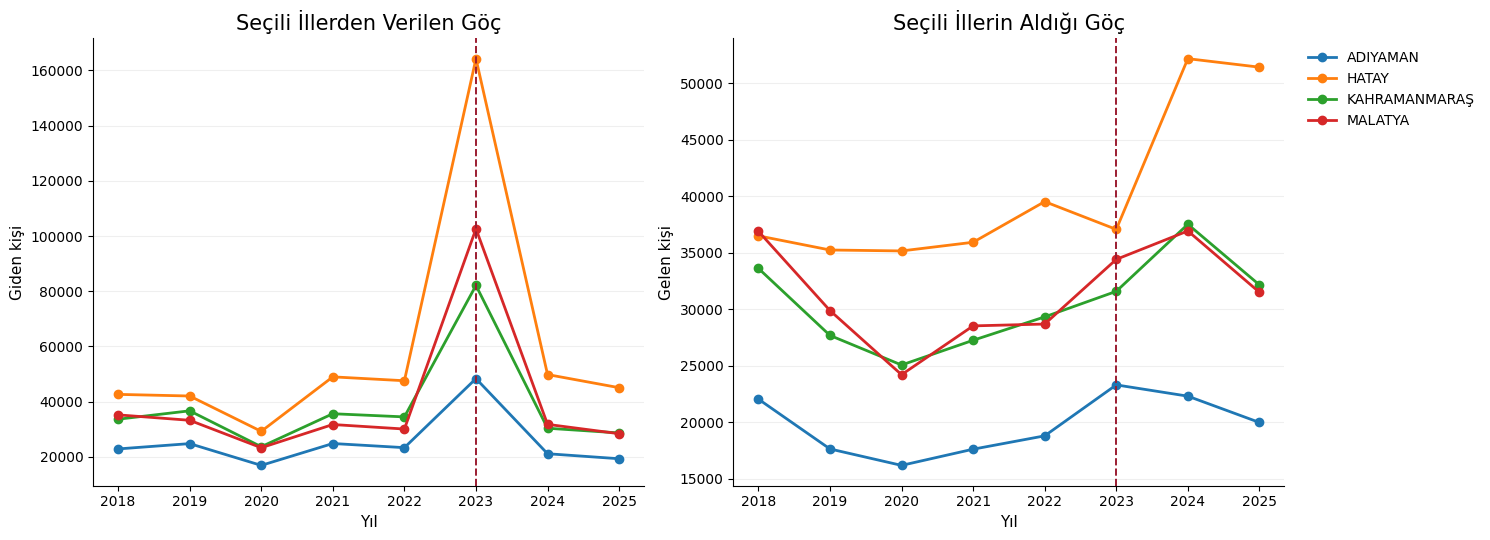

**Veri temelli yorum.** Seçili dört ilin toplam verdiği göç 2022'de 135,561 iken 2023'te 397,359 oldu. Toplam alınan göç 2024'te 148,943, 2025'te 135,051. Seriler belirgin bir yapısal kırılma gösterse de grafikten bireysel geri dönüş veya nedensellik izlenemez.

In [17]:
earthquake_provinces = ["HATAY", "MALATYA", "KAHRAMANMARAŞ", "ADIYAMAN"]
earthquake_history = city_year.loc[
    city_year.province.isin(earthquake_provinces) & city_year.year.ge(2018)
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for province, history in earthquake_history.groupby("province"):
    axes[0].plot(history.year, history.out_migration, marker="o", linewidth=2, label=province)
    axes[1].plot(history.year, history.in_migration, marker="o", linewidth=2, label=province)
for ax, title, label in [
    (axes[0], "Seçili İllerden Verilen Göç", "Giden kişi"),
    (axes[1], "Seçili İllerin Aldığı Göç", "Gelen kişi"),
]:
    ax.axvline(2023, color=RED, linestyle="--", linewidth=1.4)
    ax.set(title=title, xlabel="Yıl", ylabel=label)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

out_2022 = earthquake_history.loc[earthquake_history.year.eq(2022), "out_migration"].sum()
out_2023 = earthquake_history.loc[earthquake_history.year.eq(2023), "out_migration"].sum()
in_2024 = earthquake_history.loc[earthquake_history.year.eq(2024), "in_migration"].sum()
in_2025 = earthquake_history.loc[earthquake_history.year.eq(2025), "in_migration"].sum()
display(Markdown(
    f"**Veri temelli yorum.** Seçili dört ilin toplam verdiği göç 2022'de {out_2022:,.0f} iken "
    f"2023'te {out_2023:,.0f} oldu. Toplam alınan göç 2024'te {in_2024:,.0f}, 2025'te {in_2025:,.0f}. "
    "Seriler belirgin bir yapısal kırılma gösterse de grafikten bireysel geri dönüş veya nedensellik izlenemez."
))

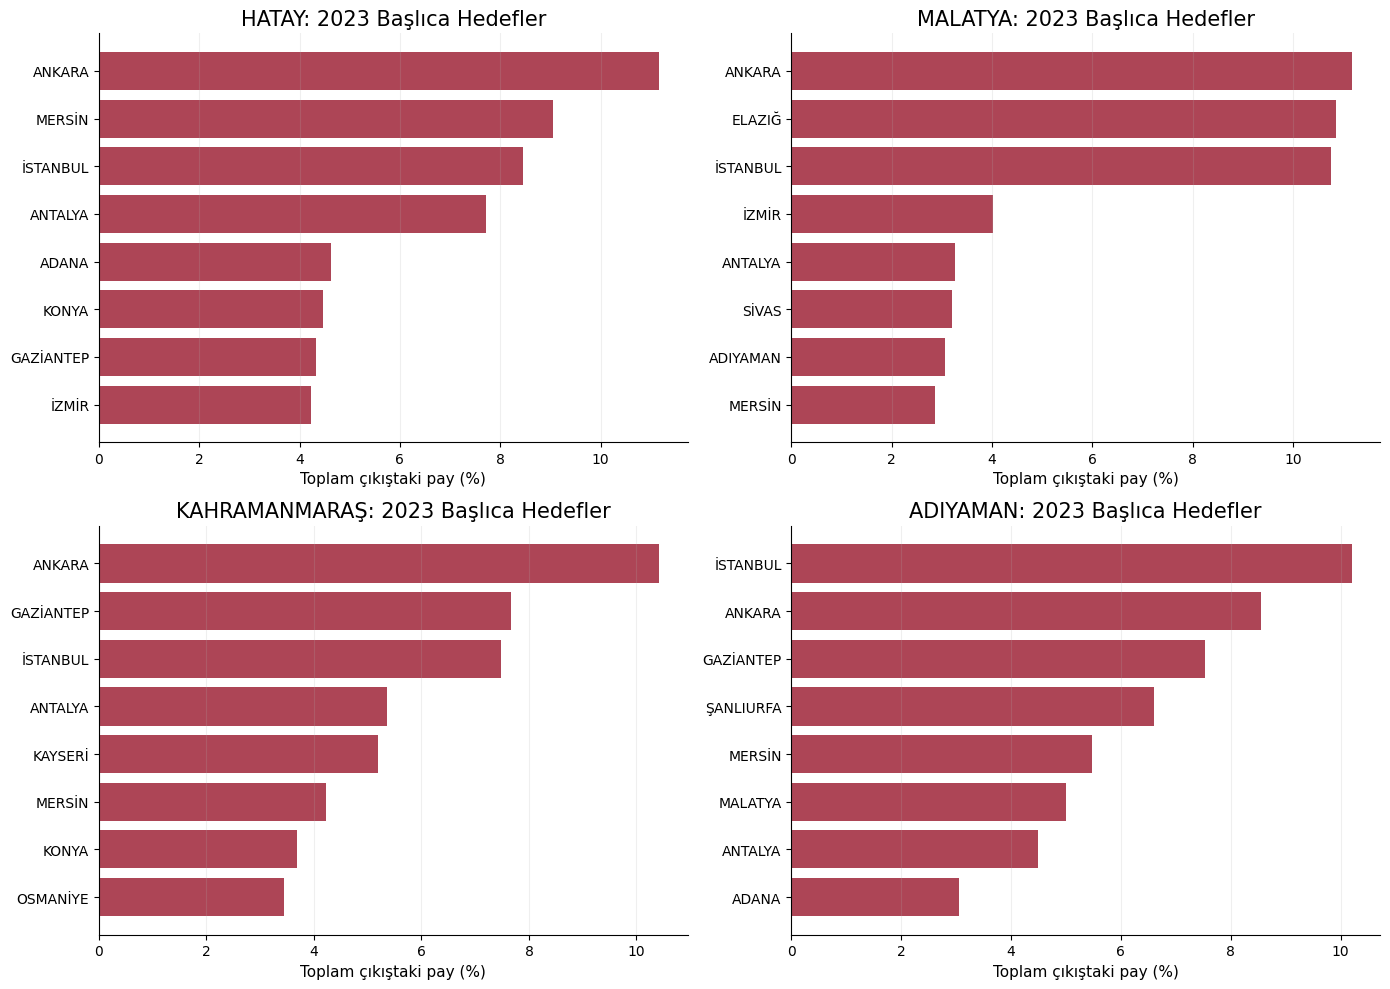

**Veri temelli yorum.** 2023'te her ilin en büyük yönlü çıkışı: HATAY → ANKARA (18,356); MALATYA → ANKARA (11,470); KAHRAMANMARAŞ → ANKARA (8,564); ADIYAMAN → İSTANBUL (4,938). Pay grafikleri illerin farklı hedef bileşimlerini gösterir; hedefleri barınma nedeni veya kalıcı yerleşim olarak etiketlemez.

In [18]:
flows_2023 = flows.loc[flows.year.eq(2023)]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, province in zip(axes.flat, earthquake_provinces):
    province_flows = flows_2023.loc[flows_2023.origin_province.eq(province)]
    total_out = province_flows.migration_flow.sum()
    routes = province_flows.nlargest(8, "migration_flow").sort_values("migration_flow").copy()
    routes["share"] = 100 * routes.migration_flow / total_out
    ax.barh(routes.destination_province, routes.share, color=RED, alpha=0.82)
    ax.set(title=f"{province}: 2023 Başlıca Hedefler", xlabel="Toplam çıkıştaki pay (%)", ylabel="")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

route_leaders = []
for province in earthquake_provinces:
    leader = flows_2023.loc[flows_2023.origin_province.eq(province)].nlargest(1, "migration_flow").iloc[0]
    route_leaders.append(f"{province} → {leader.destination_province} ({leader.migration_flow:,.0f})")
display(Markdown(
    "**Veri temelli yorum.** 2023'te her ilin en büyük yönlü çıkışı: " + "; ".join(route_leaders) + ". "
    "Pay grafikleri illerin farklı hedef bileşimlerini gösterir; hedefleri barınma nedeni veya kalıcı yerleşim olarak etiketlemez."
))

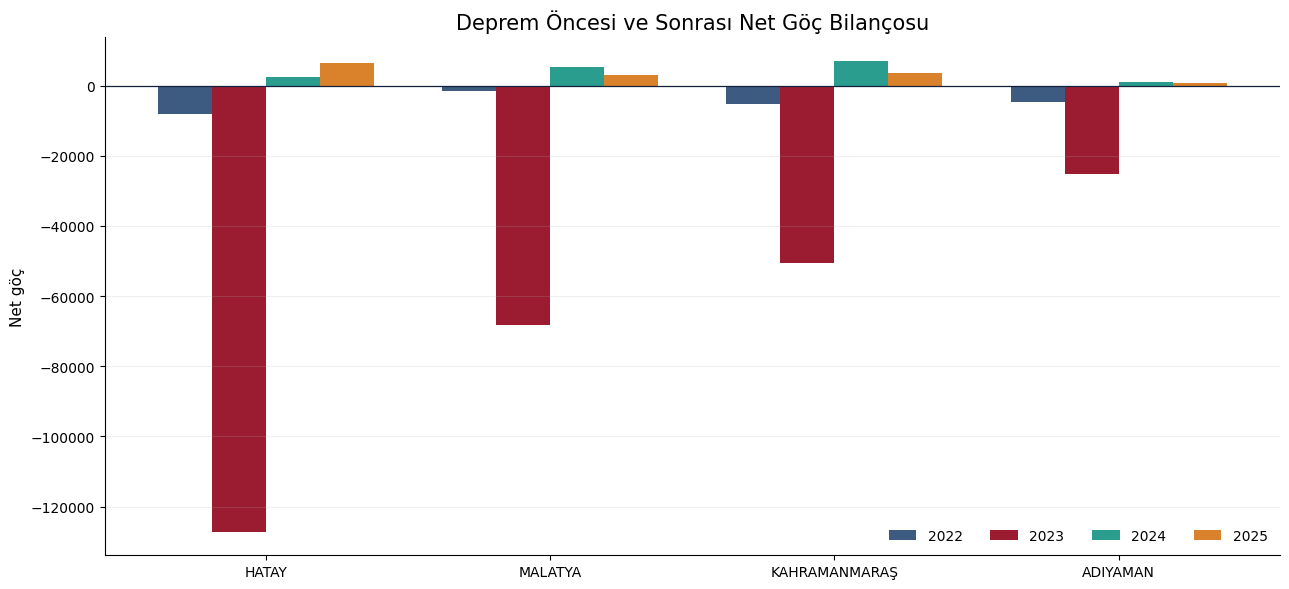

**Veri temelli yorum.** 2023 net dengeleri dört ilin tamamında negatiftir: HATAY -127,179, MALATYA -68,207, KAHRAMANMARAŞ -50,537, ADIYAMAN -25,078. 2024 ve 2025 barları, sonraki yıllarda dengenin hangi yönde değiştiğini gösterir; bu değişim aynı kişilerin geri döndüğünü kanıtlamaz.

In [19]:
balance = earthquake_history.loc[earthquake_history.year.isin([2022, 2023, 2024, 2025])]
years = [2022, 2023, 2024, 2025]
x = np.arange(len(earthquake_provinces))
width = 0.19
colors = [BLUE, RED, "#2A9D8F", "#D9822B"]

fig, ax = plt.subplots(figsize=(13, 6))
for index, (year, color) in enumerate(zip(years, colors)):
    values = balance.loc[balance.year.eq(year)].set_index("province").reindex(earthquake_provinces).net_migration
    ax.bar(x + (index - 1.5) * width, values, width=width, label=str(year), color=color)
ax.axhline(0, color=NAVY, linewidth=0.9)
ax.set_xticks(x, earthquake_provinces)
ax.set(title="Deprem Öncesi ve Sonrası Net Göç Bilançosu", ylabel="Net göç", xlabel="")
ax.legend(frameon=False, ncol=4)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

balance_pivot = balance.pivot(index="province", columns="year", values="net_migration")
display(Markdown(
    "**Veri temelli yorum.** 2023 net dengeleri dört ilin tamamında negatiftir: "
    + ", ".join(f"{province} {balance_pivot.loc[province, 2023]:,.0f}" for province in earthquake_provinces)
    + ". 2024 ve 2025 barları, sonraki yıllarda dengenin hangi yönde değiştiğini gösterir; "
      "bu değişim aynı kişilerin geri döndüğünü kanıtlamaz."
))

### 04.11 — Coğrafi Bölgeler Arası Makro Akış

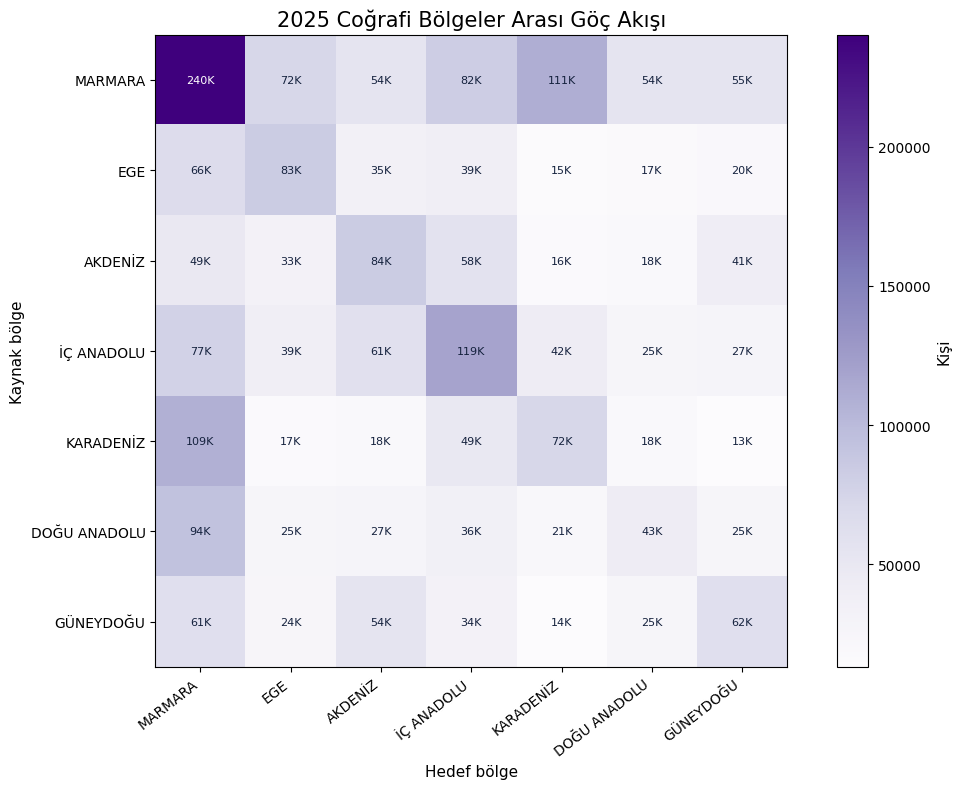

**Veri temelli yorum.** En büyük bölgeler arası yönlü akış MARMARA → KARADENİZ: 110,550 kişi. Toplam hareketin %28.4'i aynı coğrafi bölge içinde gerçekleşmiştir. Bölge eşlemesi bu betimleyici analizde kullanılır; clustering modeline girdi değildir.

In [20]:
regions = {
    "MARMARA": ["İSTANBUL", "EDİRNE", "KIRKLARELİ", "TEKİRDAĞ", "ÇANAKKALE", "KOCAELİ", "YALOVA", "SAKARYA", "BİLECİK", "BURSA", "BALIKESİR"],
    "EGE": ["İZMİR", "MANİSA", "AYDIN", "DENİZLİ", "MUĞLA", "AFYONKARAHİSAR", "KÜTAHYA", "UŞAK"],
    "AKDENİZ": ["ANTALYA", "BURDUR", "ISPARTA", "MERSİN", "ADANA", "HATAY", "OSMANİYE", "KAHRAMANMARAŞ"],
    "İÇ ANADOLU": ["ANKARA", "KONYA", "KARAMAN", "KIRIKKALE", "KIRŞEHİR", "YOZGAT", "NEVŞEHİR", "NİĞDE", "AKSARAY", "KAYSERİ", "SİVAS", "ESKİŞEHİR", "ÇANKIRI"],
    "KARADENİZ": ["AMASYA", "ARTVİN", "BARTIN", "BAYBURT", "BOLU", "ÇORUM", "DÜZCE", "GİRESUN", "GÜMÜŞHANE", "KARABÜK", "KASTAMONU", "ORDU", "RİZE", "SAMSUN", "SİNOP", "TOKAT", "TRABZON", "ZONGULDAK"],
    "DOĞU ANADOLU": ["AĞRI", "ARDAHAN", "BİNGÖL", "BİTLİS", "ELAZIĞ", "ERZİNCAN", "ERZURUM", "HAKKARİ", "IĞDIR", "KARS", "MALATYA", "MUŞ", "TUNCELİ", "VAN"],
    "GÜNEYDOĞU": ["ADIYAMAN", "BATMAN", "DİYARBAKIR", "GAZİANTEP", "KİLİS", "MARDİN", "SİİRT", "ŞANLIURFA", "ŞIRNAK"],
}
province_to_region = {province: region for region, provinces in regions.items() for province in provinces}
region_flows = flows.loc[flows.year.eq(2025)].assign(
    origin_region=lambda frame: frame.origin_province.map(province_to_region),
    destination_region=lambda frame: frame.destination_province.map(province_to_region),
)
assert region_flows[["origin_region", "destination_region"]].notna().all().all()
region_order = list(regions)
region_matrix = region_flows.pivot_table(
    index="origin_region", columns="destination_region", values="migration_flow", aggfunc="sum"
).reindex(index=region_order, columns=region_order)

fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(region_matrix, cmap="Purples")
for row in range(len(region_order)):
    for column in range(len(region_order)):
        value = region_matrix.iloc[row, column]
        ax.text(column, row, f"{value / 1000:.0f}K", ha="center", va="center", fontsize=8,
                color="white" if value > region_matrix.to_numpy().max() * 0.5 else NAVY)
ax.set_xticks(range(len(region_order)), region_order, rotation=38, ha="right")
ax.set_yticks(range(len(region_order)), region_order)
ax.set(title="2025 Coğrafi Bölgeler Arası Göç Akışı", xlabel="Hedef bölge", ylabel="Kaynak bölge")
fig.colorbar(image, ax=ax, label="Kişi")
plt.tight_layout()
plt.show()

interregional = region_flows.loc[region_flows.origin_region.ne(region_flows.destination_region)]
region_pair = (
    interregional.groupby(["origin_region", "destination_region"], as_index=False).migration_flow.sum()
    .nlargest(1, "migration_flow").iloc[0]
)
intra_share = 100 * region_flows.loc[
    region_flows.origin_region.eq(region_flows.destination_region), "migration_flow"
].sum() / region_flows.migration_flow.sum()
display(Markdown(
    f"**Veri temelli yorum.** En büyük bölgeler arası yönlü akış {region_pair.origin_region} → "
    f"{region_pair.destination_region}: {region_pair.migration_flow:,.0f} kişi. Toplam hareketin %{intra_share:.1f}'i "
    "aynı coğrafi bölge içinde gerçekleşmiştir. Bölge eşlemesi bu betimleyici analizde kullanılır; clustering modeline girdi değildir."
))

## 05 — Göç Ağı Analizi

In [21]:
network_metrics = province_network_metrics(flows, 2025)
network_metrics.head(10).style.format({
    "weighted_in_strength": "{:,.0f}",
    "weighted_out_strength": "{:,.0f}",
    "network_net_flow": "{:,.0f}",
    "pagerank": "{:.4f}",
})

,province,weighted_in_strength,weighted_out_strength,pagerank,network_net_flow
0,İSTANBUL,"329,912","371,258",0.1193,"-41,346"
1,ANKARA,"176,833","145,661",0.0641,"31,172"
2,İZMİR,"106,083","98,728",0.0382,"7,355"
3,ANTALYA,"96,027","67,649",0.0342,"28,378"
4,BURSA,"75,595","64,880",0.0276,"10,715"
5,KOCAELİ,"76,323","61,245",0.0271,"15,078"
6,MERSİN,"57,089","52,054",0.0212,"5,035"
7,GAZİANTEP,"54,507","47,385",0.0201,"7,122"
8,KONYA,"50,469","51,507",0.0198,"-1,038"
9,HATAY,"51,440","45,076",0.0197,"6,364"


### 05.1 — En Yüksek Hacimli Akışların Ağ Görünümü

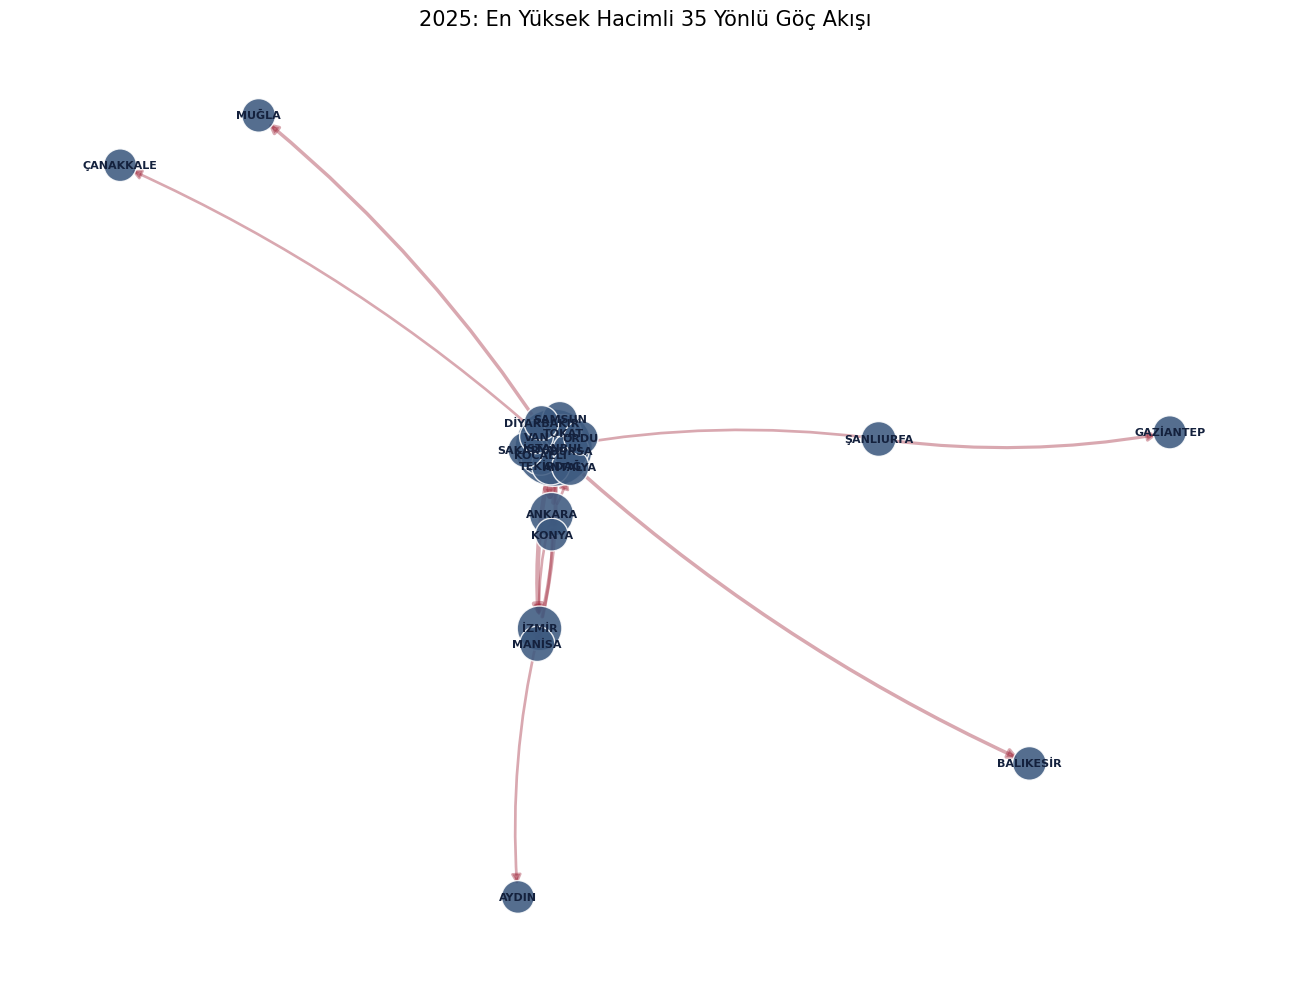

**Ağ yorumu.** Bu görsel yalnızca en yüksek hacimli 35 akışı gösterir; tam 81-il ağı değildir. Düğüm büyüklüğü seçili alt ağdaki ağırlıklı toplam bağlantıyı, oklar kaynak→hedef yönünü ve çizgi kalınlığı akış hacmini temsil eder.

In [22]:
top_network_flows = strongest_corridors(flows, 2025, top_n=35)
graph = nx.from_pandas_edgelist(
    top_network_flows,
    source="origin",
    target="destination",
    edge_attr="flow",
    create_using=nx.DiGraph,
)
layout = nx.spring_layout(graph, seed=42, weight="flow", k=1.3)
node_strength = dict(graph.degree(weight="flow"))
node_sizes = [500 + 2600 * node_strength[node] / max(node_strength.values()) for node in graph.nodes]
edge_widths = [0.8 + 4 * graph[source][target]["flow"] / top_network_flows.flow.max() for source, target in graph.edges]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(graph, layout, node_size=node_sizes, node_color=BLUE, alpha=0.88, edgecolors="white", ax=ax)
nx.draw_networkx_edges(graph, layout, width=edge_widths, edge_color=RED, alpha=0.38,
                       arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.08", ax=ax)
nx.draw_networkx_labels(graph, layout, font_size=8, font_weight="bold", font_color=NAVY, ax=ax)
ax.set_title("2025: En Yüksek Hacimli 35 Yönlü Göç Akışı")
ax.axis("off")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Ağ yorumu.** Bu görsel yalnızca en yüksek hacimli 35 akışı gösterir; tam 81-il ağı değildir. "
    "Düğüm büyüklüğü seçili alt ağdaki ağırlıklı toplam bağlantıyı, oklar kaynak→hedef yönünü ve çizgi kalınlığı akış hacmini temsil eder."
))

> **Ağ yorumu**  
> Weighted in/out strength, bir ilin gerçek gelen ve giden hacmini; PageRank ise yüksek hacimli kaynaklardan aldığı akışlarla ağdaki göreli merkeziyetini özetler. Ağ 81 il arasında yoğun olduğu için betweenness metriği ayrıştırıcı bulunmamış ve final analize eklenmemiştir.

## 06 — Feature Engineering

In [23]:
features = build_long_term_features(city_year)
feature_summary = features[MODEL_FEATURES].describe().T[["mean", "std", "min", "max"]].round(3)
feature_summary

,mean,std,min,max
mean_turnover_rate,82.725,27.969,46.159,206.109
mean_net_migration_rate,-1.802,7.907,-25.498,18.173
net_migration_rate_volatility,8.963,8.374,1.582,48.445
net_migration_rate_trend,0.217,0.467,-1.491,1.561
recent_net_migration_rate,-0.036,8.965,-25.612,23.615
latest_population_log,13.298,0.978,11.325,16.573


Model tek yıllık fotoğraf yerine 2008–2025 ortalama hareketlilik ve net hızını, net hız volatilitesini, doğrusal trendi, 2023–2025 yakın dönem ortalamasını ve 2025 log-nüfusunu kullanır. Manuel deprem bayrağı ve bölge dummy'leri modele alınmamış; segmentasyonun kaynaklı olmayan dış etiketlerle zorlanması önlenmiştir.

## 07 — Clustering Model Karşılaştırması

In [24]:
model_result = train_and_save_models(city_year)
evaluation = model_result["evaluation"].copy()
metadata = model_result["metadata"]
selected_k = metadata["selected_k"]

evaluation.style.format({
    "inertia": "{:.2f}",
    "silhouette": "{:.3f}",
    "davies_bouldin": "{:.3f}",
    "calinski_harabasz": "{:.2f}",
    "stability_ari": "{:.3f}",
    "max_cluster_share": "{:.1%}",
}).apply(lambda row: ["background-color:#FDECEF" if row["k"] == selected_k else "" for _ in row], axis=1)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,stability_ari,min_cluster_size,max_cluster_share
0,2,365.17,0.548,0.729,26.14,1.000,4,95.1%
1,3,270.56,0.307,1.129,31.05,0.939,4,71.6%
2,4,199.62,0.298,1.031,36.82,0.993,4,50.6%
3,5,173.54,0.245,1.162,34.21,0.841,4,34.6%
4,6,153.61,0.238,1.176,32.46,0.814,4,32.1%
5,7,135.27,0.252,1.103,31.98,0.814,4,32.1%
6,8,122.84,0.225,1.077,30.83,0.587,4,21.0%


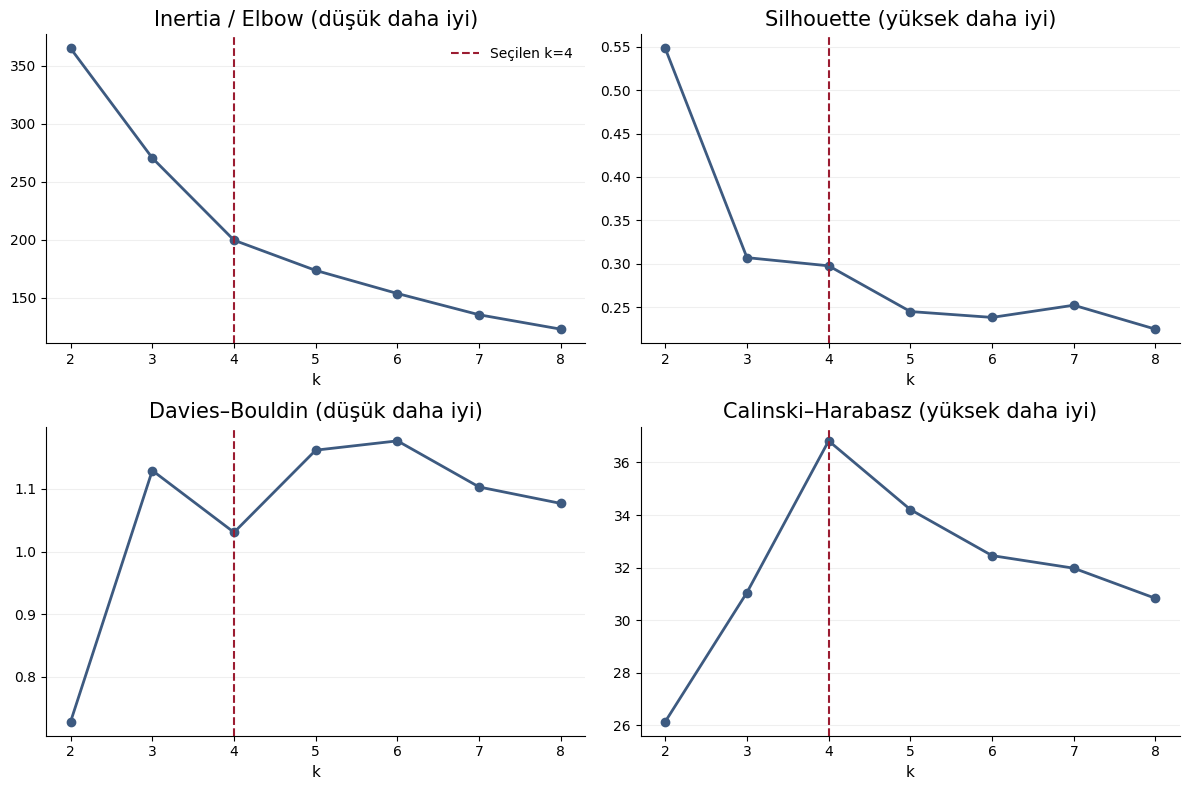

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metric_specs = [
    ("inertia", "Inertia / Elbow", "düşük"),
    ("silhouette", "Silhouette", "yüksek"),
    ("davies_bouldin", "Davies–Bouldin", "düşük"),
    ("calinski_harabasz", "Calinski–Harabasz", "yüksek"),
]
for ax, (column, title, direction) in zip(axes.flat, metric_specs):
    ax.plot(evaluation.k, evaluation[column], color=BLUE, marker="o", linewidth=2)
    ax.axvline(selected_k, color=RED, linestyle="--", label=f"Seçilen k={selected_k}")
    ax.set(title=f"{title} ({direction} daha iyi)", xlabel="k")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
axes[0, 0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [26]:
metrics = metadata["evaluation_metrics"]
hdbscan = metadata["hdbscan_comparison"]
display(Markdown(
    f"**Model seçimi.** k={selected_k}; Silhouette {metrics['silhouette']:.3f}, "
    f"Davies–Bouldin {metrics['davies_bouldin']:.3f}, Calinski–Harabasz {metrics['calinski_harabasz']:.2f}, "
    f"seed stability ARI {metrics['stability_ari']:.3f}. HDBSCAN {hdbscan['cluster_count']} küme ve "
    f"{hdbscan['noise_count']} noise il üretti. K-Means yeni gözlemlere profil atayabildiği için production modeli, "
    f"HDBSCAN keşifsel karşılaştırmadır."
))

**Model seçimi.** k=4; Silhouette 0.298, Davies–Bouldin 1.031, Calinski–Harabasz 36.82, seed stability ARI 0.993. HDBSCAN 2 küme ve 25 noise il üretti. K-Means yeni gözlemlere profil atayabildiği için production modeli, HDBSCAN keşifsel karşılaştırmadır.

## 08 — PCA ve Cluster Yorumlama

In [27]:
profiles = model_result["features"]
variance = metadata["pca_explained_variance_ratio"]
fig = px.scatter(
    profiles,
    x="pc1",
    y="pc2",
    color="cluster_name",
    hover_name="province",
    hover_data={
        "cluster_name": False,
        "latest_population": ":,",
        "mean_turnover_rate": ":.1f",
        "mean_net_migration_rate": ":.1f",
        "recent_net_migration_rate": ":.1f",
        "pc1": False,
        "pc2": False,
    },
    labels={"cluster_name": "Göç profili", "pc1": "PC1", "pc2": "PC2"},
    title="PCA Düzleminde 2008–2025 İl Profilleri",
    color_discrete_sequence=[RED, BLUE, "#2A9D8F", "#D9822B"],
)
fig.update_traces(marker={"size": 10, "line": {"width": 0.8, "color": "white"}}, opacity=0.88)
fig.update_layout(
    template="plotly_white",
    legend_title_text="Profil",
    xaxis_title=f"PC1 (%{variance[0] * 100:.1f})",
    yaxis_title=f"PC2 (%{variance[1] * 100:.1f})",
)
fig.show()

In [28]:
cluster_summary = (
    profiles.groupby("cluster_name")
    .agg(
        il_sayisi=("province", "size"),
        ort_hareketlilik_hizi=("mean_turnover_rate", "mean"),
        ort_net_goc_hizi=("mean_net_migration_rate", "mean"),
        son_uc_yil_net_hizi=("recent_net_migration_rate", "mean"),
        ort_2025_nufusu=("latest_population", "mean"),
    )
    .round(2)
    .sort_values("ort_2025_nufusu", ascending=False)
)
cluster_summary

,il_sayisi,ort_hareketlilik_hizi,ort_net_goc_hizi,son_uc_yil_net_hizi,ort_2025_nufusu
cluster_name,,,,,
Büyük Ölçekli Çekim Merkezleri,22,60.92,3.39,3.95,2704582.73
Süregelen Net Göç Veren İller,14,78.65,-13.34,-14.90,623750.86
Dengeli Orta Hareketlilik,41,86.77,-0.87,2.70,423208.80
Küçük Ölçekli Yüksek Hareketlilik,4,175.43,0.45,1.98,126818.75


### 08.1 — Cluster Dağılımı ve Standardize Profil Ortalamaları

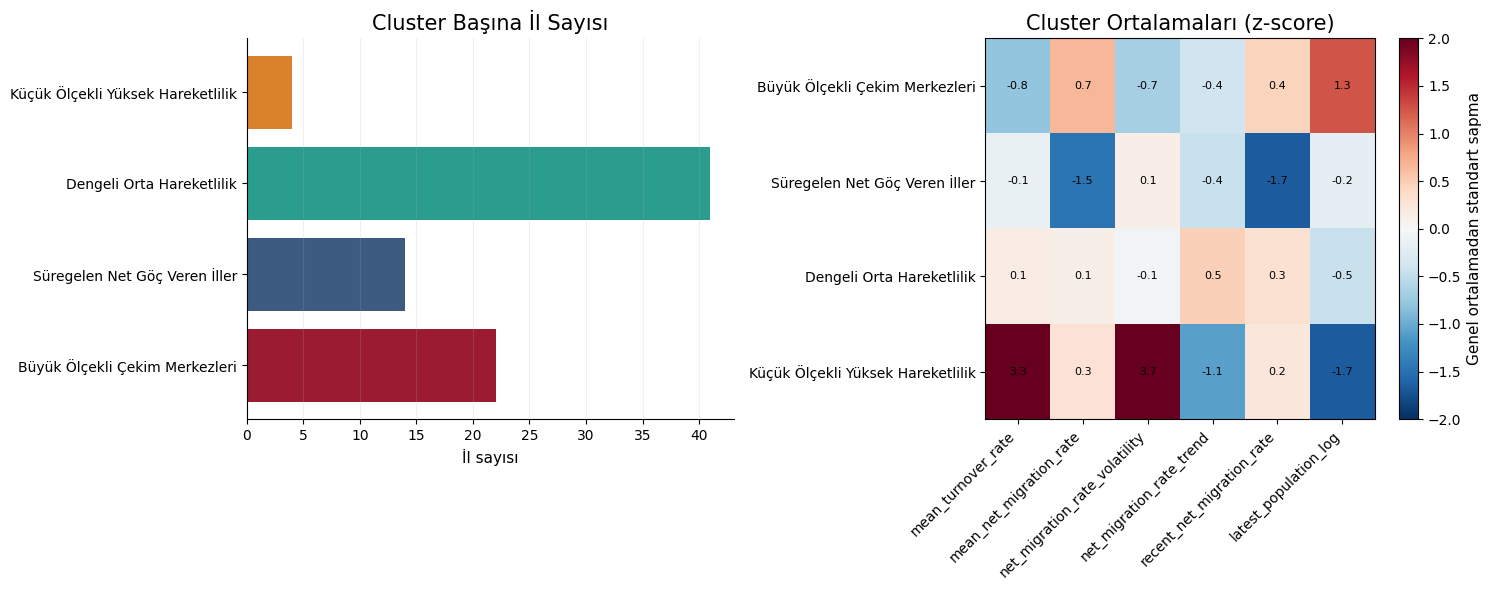

**Model yorumu.** Sol panel segmentlerin boyut dengesini, sağ panel ise profil isimlerinin dayandığı göreli özellik farklarını gösterir. Kırmızı tonlar genel ortalamanın üzerini, mavi tonlar altını ifade eder; bu değerler ham göç sayıları değildir.

In [29]:
cluster_order = profiles.groupby("cluster_name").latest_population.mean().sort_values(ascending=False).index
cluster_counts = profiles.cluster_name.value_counts().reindex(cluster_order)
standardized_features = (profiles[MODEL_FEATURES] - profiles[MODEL_FEATURES].mean()) / profiles[MODEL_FEATURES].std(ddof=0)
centroid_z = standardized_features.assign(cluster_name=profiles.cluster_name).groupby("cluster_name").mean().reindex(cluster_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(cluster_counts.index, cluster_counts.values, color=[RED, BLUE, "#2A9D8F", "#D9822B"])
axes[0].set(title="Cluster Başına İl Sayısı", xlabel="İl sayısı", ylabel="")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="x", alpha=0.2)

image = axes[1].imshow(centroid_z, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
for row in range(centroid_z.shape[0]):
    for column in range(centroid_z.shape[1]):
        axes[1].text(column, row, f"{centroid_z.iloc[row, column]:.1f}", ha="center", va="center", fontsize=8)
axes[1].set_xticks(range(len(MODEL_FEATURES)), MODEL_FEATURES, rotation=45, ha="right")
axes[1].set_yticks(range(len(cluster_order)), cluster_order)
axes[1].set_title("Cluster Ortalamaları (z-score)")
fig.colorbar(image, ax=axes[1], label="Genel ortalamadan standart sapma")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Model yorumu.** Sol panel segmentlerin boyut dengesini, sağ panel ise profil isimlerinin dayandığı "
    "göreli özellik farklarını gösterir. Kırmızı tonlar genel ortalamanın üzerini, mavi tonlar altını ifade eder; "
    "bu değerler ham göç sayıları değildir."
))

### 08.2 — K-Means ve HDBSCAN'in PCA Düzleminde Karşılaştırılması

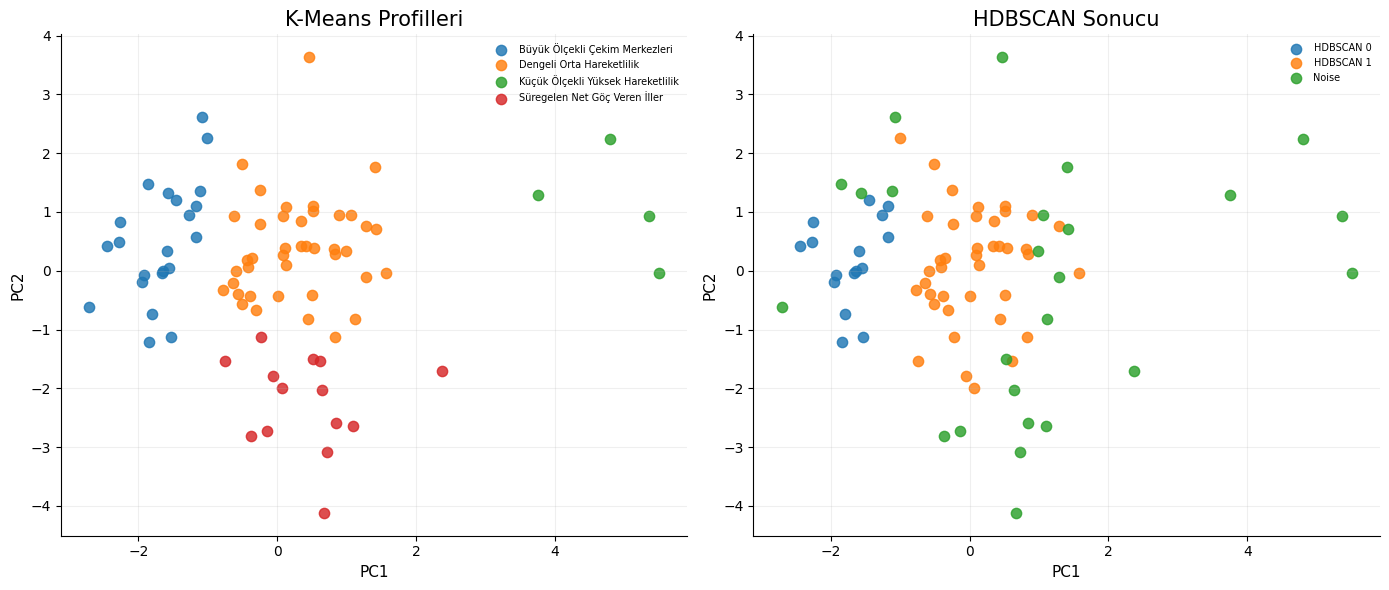

**Model karşılaştırması.** HDBSCAN 2 küme ve 25 noise il üretir. K-Means tüm illere tekrar kullanılabilir profil atarken, HDBSCAN daha muhafazakâr yoğunluk yapısı nedeniyle çok sayıda ili noise olarak bırakır.

In [30]:
cluster_pipeline = joblib.load(MODELS_DIR / "migration_cluster_pipeline.joblib")
scaled_features = cluster_pipeline.named_steps["preprocess"].transform(profiles[MODEL_FEATURES])
hdbscan_labels = HDBSCAN(min_cluster_size=4, min_samples=2).fit_predict(scaled_features)
hdbscan_names = np.where(hdbscan_labels == -1, "Noise", [f"HDBSCAN {value}" for value in hdbscan_labels])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, group in profiles.groupby("cluster_name"):
    axes[0].scatter(group.pc1, group.pc2, s=55, alpha=0.82, label=name)
for name in sorted(set(hdbscan_names)):
    mask = hdbscan_names == name
    axes[1].scatter(profiles.loc[mask, "pc1"], profiles.loc[mask, "pc2"], s=55, alpha=0.82, label=name)
for ax, title in zip(axes, ["K-Means Profilleri", "HDBSCAN Sonucu"]):
    ax.set(title=title, xlabel="PC1", ylabel="PC2")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Model karşılaştırması.** HDBSCAN {len(set(hdbscan_labels) - {-1})} küme ve "
    f"{int((hdbscan_labels == -1).sum())} noise il üretir. K-Means tüm illere tekrar kullanılabilir profil atarken, "
    "HDBSCAN daha muhafazakâr yoğunluk yapısı nedeniyle çok sayıda ili noise olarak bırakır."
))

PCA clustering yapmaz; standardize edilmiş özellikleri iki boyutta görselleştirir. Profil adları sabit eşiklerden değil, cluster centroidlerinin nüfus, hareketlilik ve net göç sıralamalarından üretilmiştir.

## 09 — Model Evaluation

In [31]:
pipeline = joblib.load(MODELS_DIR / "migration_cluster_pipeline.joblib")
reloaded_labels = pipeline.predict(profiles[MODEL_FEATURES])
reload_consistency = np.array_equal(reloaded_labels, profiles.cluster_id.to_numpy())

pd.DataFrame({
    "Kontrol": ["Model reload tutarlılığı", "Seed stability ARI", "PCA açıklanan toplam varyans"],
    "Sonuç": [reload_consistency, round(metrics["stability_ari"], 3), f"%{100 * sum(variance):.1f}"],
})

,Kontrol,Sonuç
0,Model reload tutarlılığı,True
1,Seed stability ARI,0.993
2,PCA açıklanan toplam varyans,%70.5


> **Değerlendirme sınırı**  
> Accuracy, precision ve F1 kullanılmamıştır; clustering supervised classification değildir. İçsel metrikler, farklı seed kararlılığı, küme boyutları ve yorumlanabilirlik birlikte değerlendirilmiştir.

## 10 — Final Findings

### Temel Bulgular

1. Yıllık iller arası göç 2023'te 3.450.953 kişiyle dönem zirvesine ulaştı.
2. 2025 toplamı 2.475.019 kişi; 2024'e göre %7,7 daha düşüktür.
3. İstanbul en yüksek giriş ve çıkış hacmine karşın 41.346 kişilik net kayıp vermiştir.
4. Ankara 31.172 kişiyle en yüksek mutlak net kazancı kaydetmiştir.
5. Nüfusa oranlı net göç hızında Yalova pozitif, Ağrı negatif uçta yer almıştır.
6. İstanbul → Kocaeli, 23.723 kişiyle 2025'in en büyük yönlü koridorudur.
7. 20–24 yaş grubu 480.185 kişiyle en hareketli gruptur.
8. Hane/aile ferdine bağımlı göç 564.114 kişiyle en yaygın kaydedilen nedendir.
9. Yaş, cinsiyet ve eğitim kırılımlarında göç nedeni bileşimi belirgin biçimde farklılaşmaktadır.
10. Depremden ağır etkilenen dört ilin serilerinde 2023 çevresinde belirgin kırılma vardır; bu bulgu betimleyicidir ve tek başına nedensellik veya bireysel geri dönüş kanıtı değildir.

### Model Bulguları

Dört profil ortaya çıkmıştır: **Büyük Ölçekli Çekim Merkezleri**, **Dengeli Orta Hareketlilik**, **Küçük Ölçekli Yüksek Hareketlilik** ve **Süregelen Net Göç Veren İller**. K-Means k=4 sonucu yüksek seed kararlılığı göstermiş; HDBSCAN ise çok sayıda ili noise olarak ayırarak daha muhafazakâr bir yoğunluk yapısı ortaya koymuştur. Ayrıntılı il listeleri ve centroid özetleri `cluster_metadata.json` içinde sürümlenmiştir.

### Limitations

- Demografi ve göç nedeni tabloları yalnızca 2025 kesitidir.
- 81 il, clustering için sınırlı bir örneklemdir; tek bir evrensel segmentasyon yoktur.
- Cluster'lar nedensellik veya gelecek tahmini sunmaz.
- Afet dönemi grafikleri zaman birlikteliğini gösterir; aynı kişilerin hareketini izleyen panel veri değildir.
- Gelir, istihdam, konut maliyeti ve afet etkisi gibi dış değişkenler modelde bulunmaz.

### Future Work

Kaynaklı sosyoekonomik değişkenlerin eklenmesi, bootstrap kararlılık analizi, coğrafi akış haritası ve yeni TÜİK yılları için veri/model sürümleme mekanizması en anlamlı sonraki adımlardır.